#Importing the all the required libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import LabelEncoder
from sklearn import model_selection
from sklearn.metrics import confusion_matrix,accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.mlab as mlab
import datetime
import scipy
import scipy.stats as stats
import os
from sklearn.decomposition import PCA, FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import silhouette_score

#Loading the dataset & reading first and last 5 instances of the dataset

In [ ]:
df=pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Online Retail.xlsx")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
data=df

#Analaising the dataset
###Information about dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


###Description on dataset

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


###Covariance and Correlation matrices

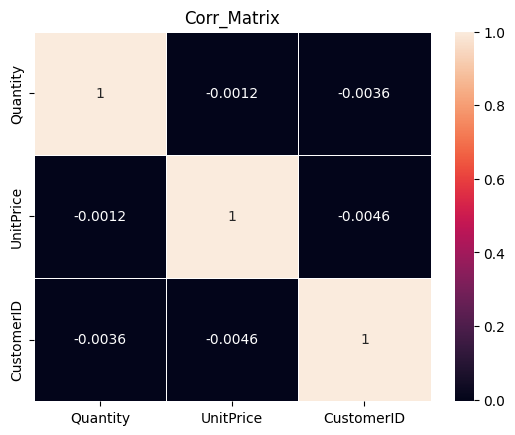

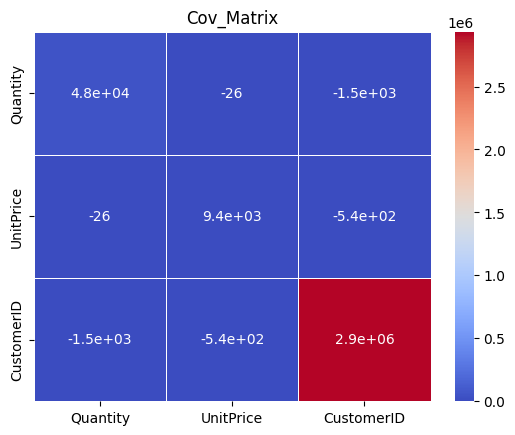

In [ ]:
corr_mat=data.corr()
sns.heatmap(corr_mat,annot=True,linewidth=.5)
plt.title('Corr_Matrix')
plt.show()
cov_mat=data.cov()
sns.heatmap(cov_mat,annot=True,linewidth=.5,cmap='coolwarm')
plt.title('Cov_Matrix')
plt.show()

#Preprocessing
###finding the no.of missing entries in each feature

In [ ]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

###finding the no.of unique entries in each feature

In [ ]:
data.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [ ]:
data['Amount']=data.Quantity*data.UnitPrice

###finding the unique value count for all catagorial features

In [ ]:
data['Description'].value_counts()

WHITE HANGING HEART T-LIGHT HOLDER     2369
REGENCY CAKESTAND 3 TIER               2200
JUMBO BAG RED RETROSPOT                2159
PARTY BUNTING                          1727
LUNCH BAG RED RETROSPOT                1638
                                       ... 
Missing                                   1
historic computer difference?....se       1
DUSTY PINK CHRISTMAS TREE 30CM            1
WRAP BLUE RUSSIAN FOLKART                 1
PINK BERTIE MOBILE PHONE CHARM            1
Name: Description, Length: 4223, dtype: int64

visualizing the sales of products

Text(0, 0.5, 'Description of Product')

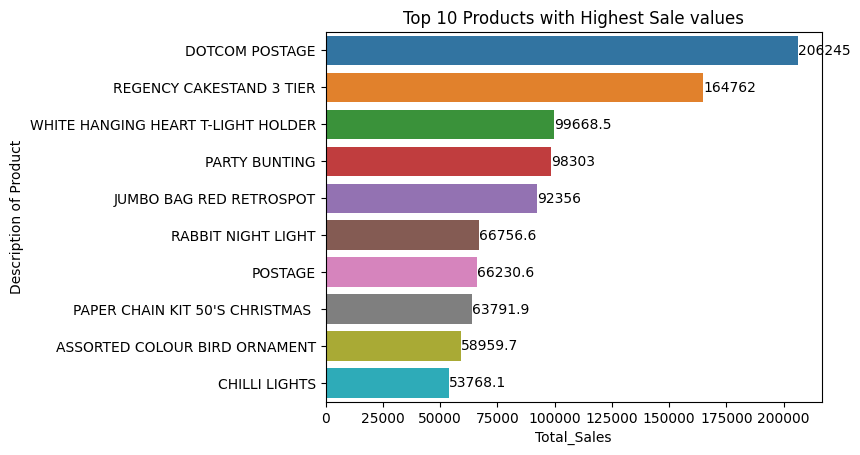

In [ ]:
snp =sns.barplot(y = 'Description' , x= 'Amount' , data = data.groupby('Description').agg({'Amount' : 'sum'}).sort_values(by = 'Amount' , ascending = False).reset_index(drop= False).head(10) )#, palette = Palette)
snp.bar_label(snp.containers[0])
plt.title('Top 10 Products with Highest Sale values')
plt.xlabel('Total_Sales')
plt.ylabel('Description of Product')

Text(0, 0.5, 'Description of Product')

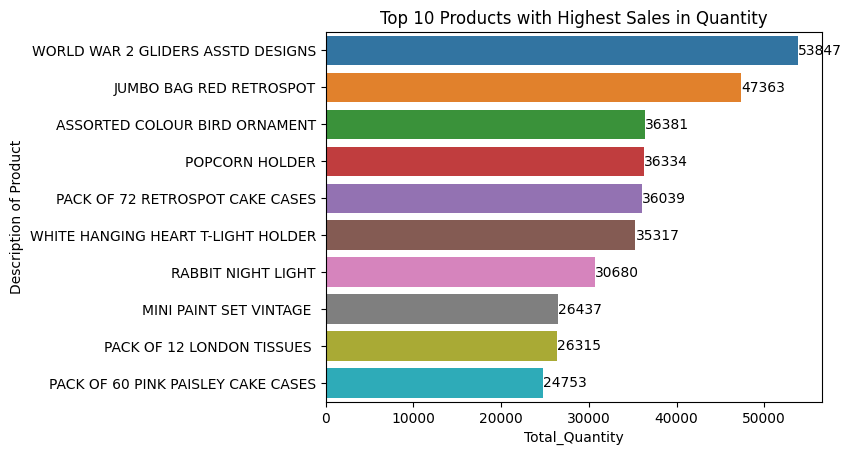

In [ ]:
snp =sns.barplot(y = 'Description' , x= 'Quantity' , data = data.groupby('Description').agg({'Quantity' : 'sum'}).sort_values(by = 'Quantity' , ascending = False).reset_index(drop= False).head(10) )#, palette = Palette)
snp.bar_label(snp.containers[0])
plt.title('Top 10 Products with Highest Sales in Quantity')
plt.xlabel('Total_Quantity')
plt.ylabel('Description of Product')

checking how many quantity of products have been sold online from each country

In [ ]:
data['Country'].value_counts()

United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58
Lebanon 

####visualizing the unitprice

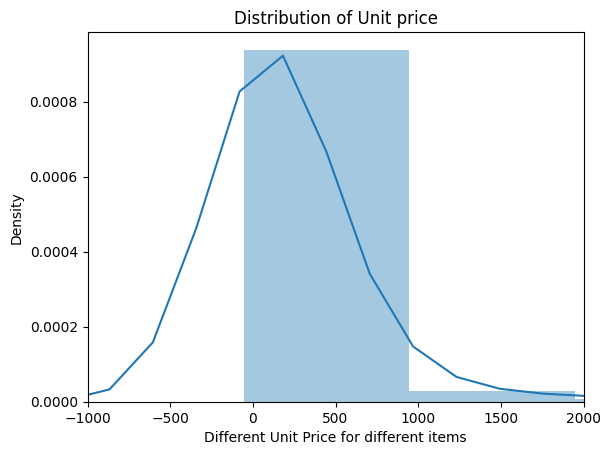

In [ ]:
sns.distplot(np.unique(data['UnitPrice']))
plt.title('Distribution of Unit price')
plt.xlabel('Different Unit Price for different items')
plt.xlim(-1000,2000)
plt.show()

#### let's look at Sales vs Invoicedate (Time series Analysis)


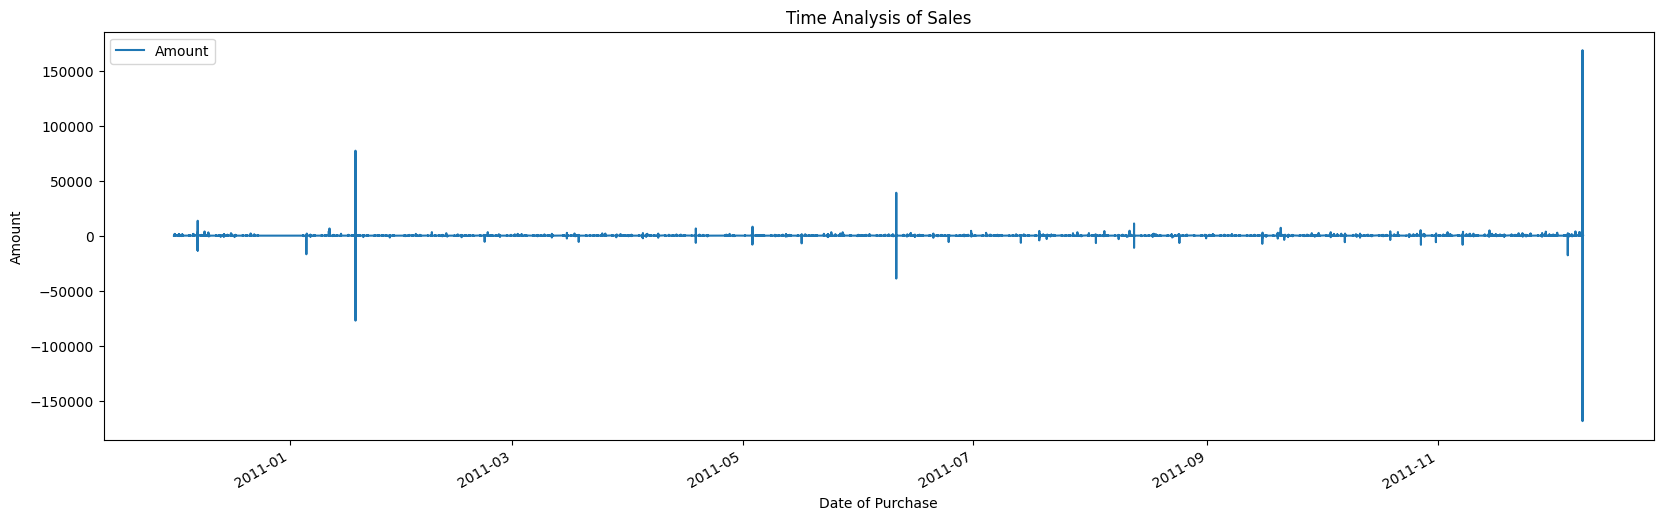

In [ ]:
plt.rcParams['figure.figsize'] = (20, 6)
data.plot(x = 'InvoiceDate', y = 'Amount')
plt.title("Time Analysis of Sales")
plt.xlabel('Date of Purchase')
plt.ylabel('Amount')
plt.show()

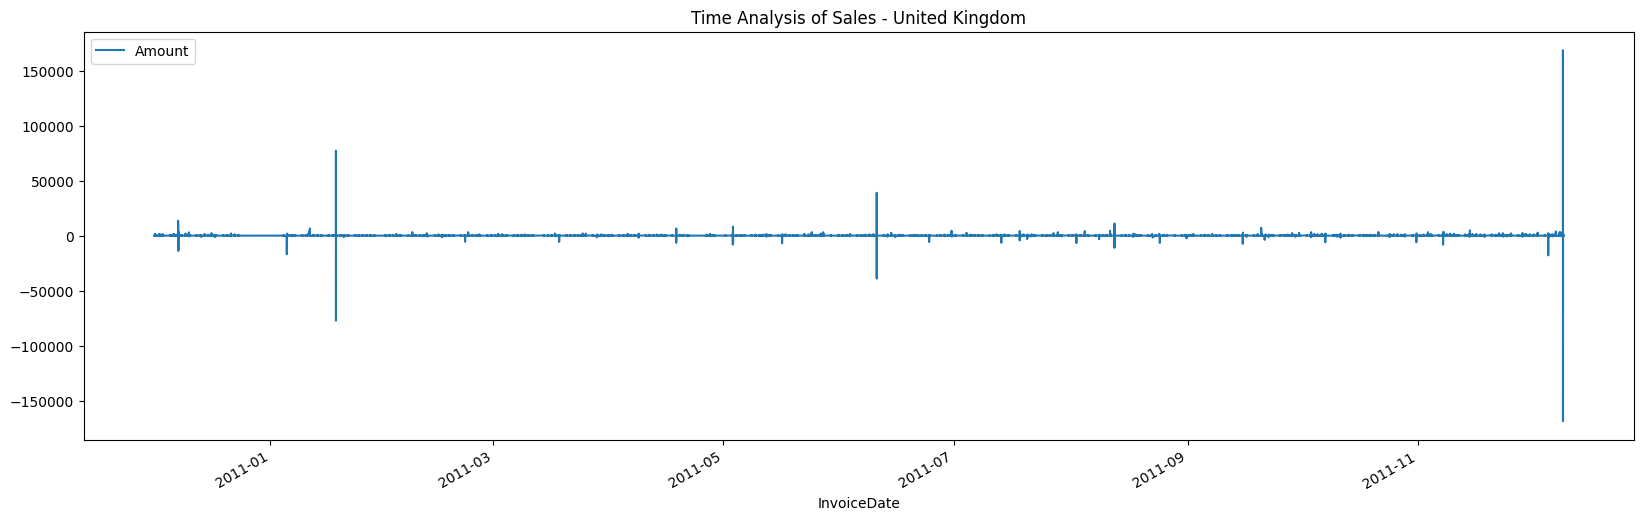

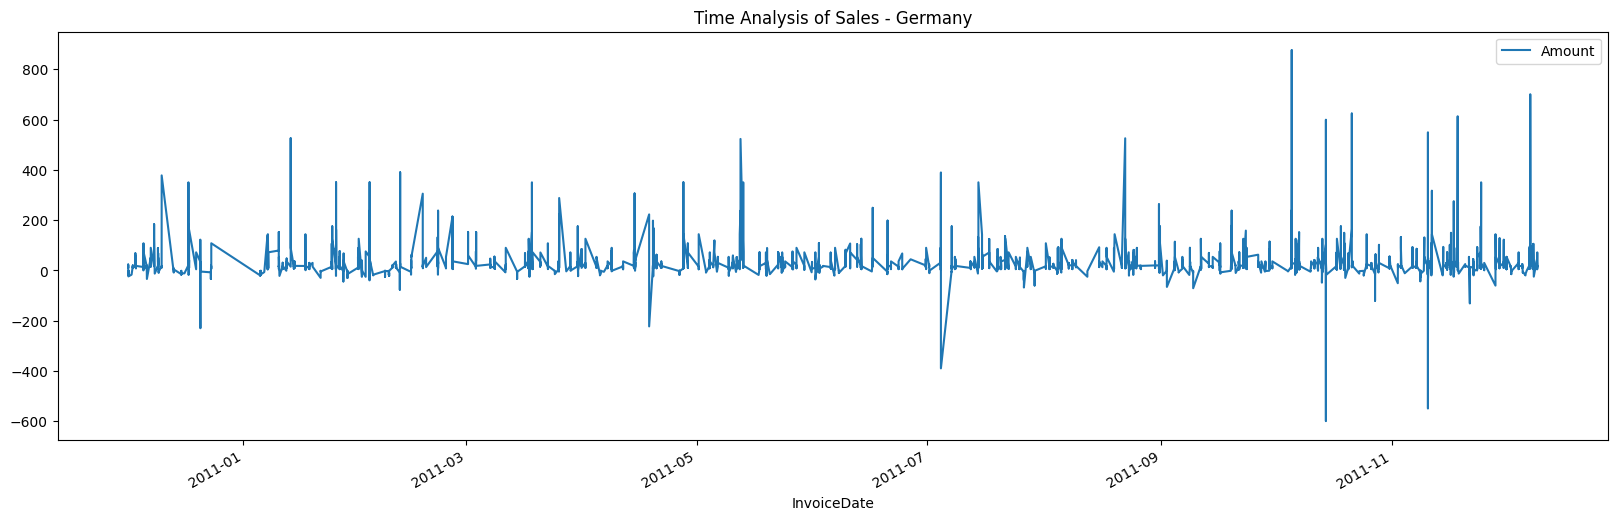

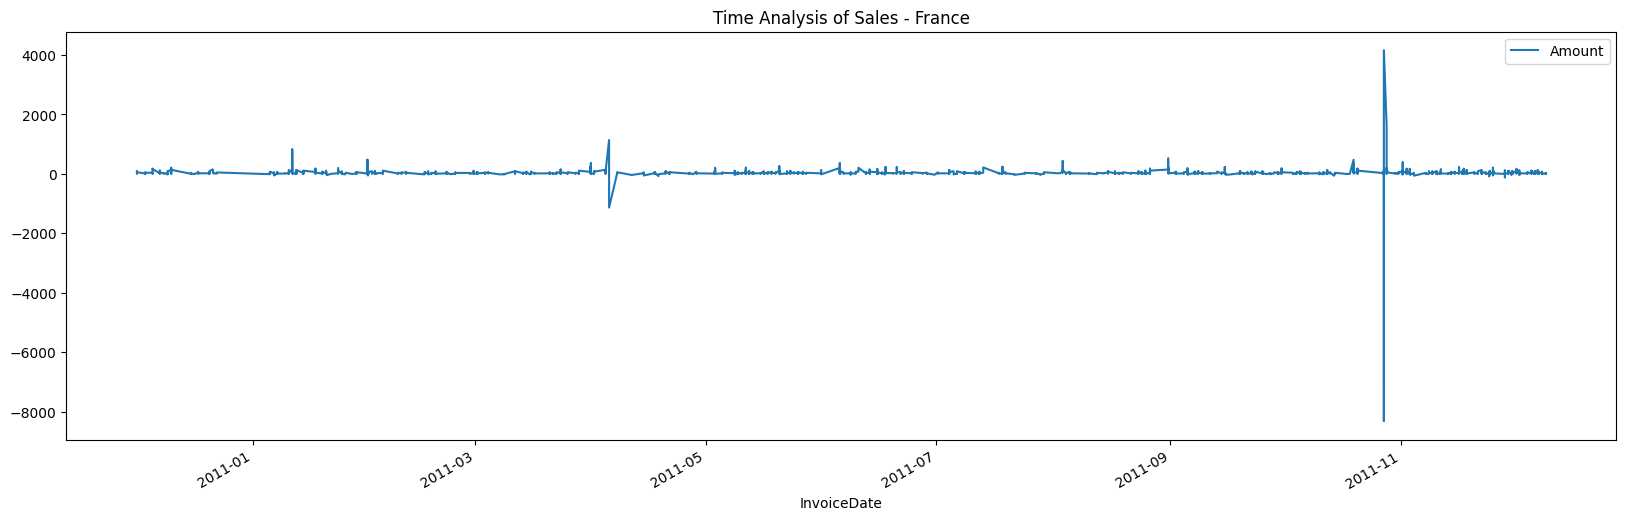

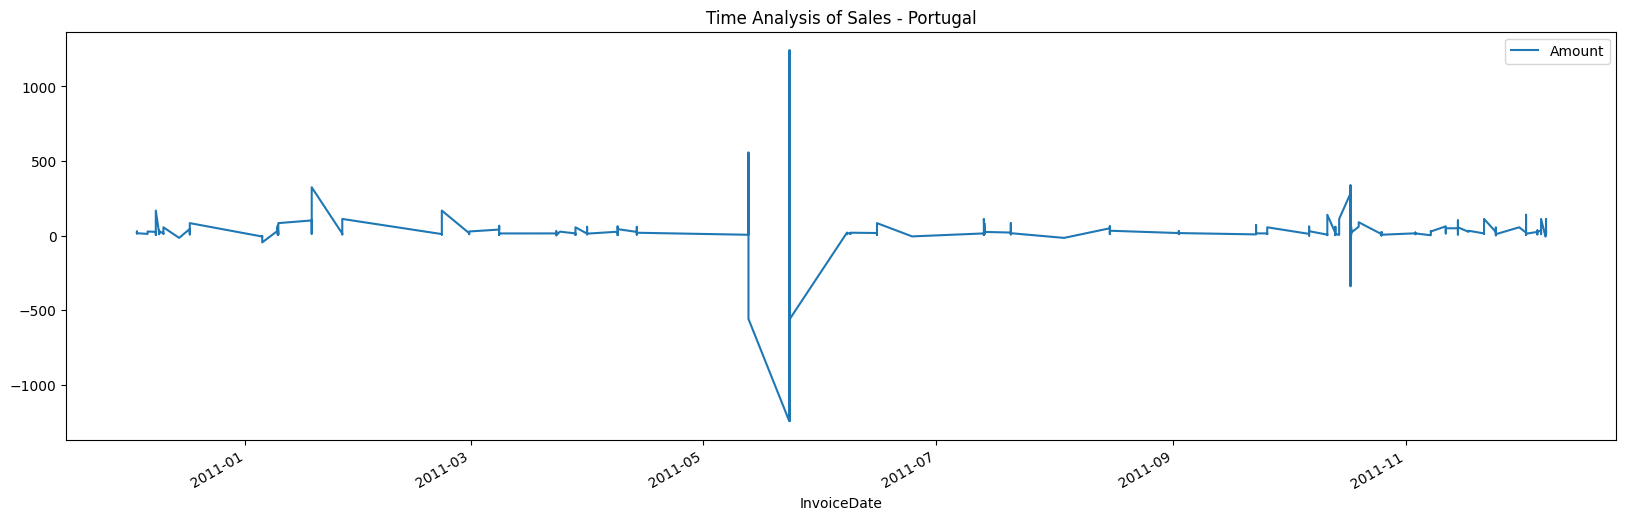

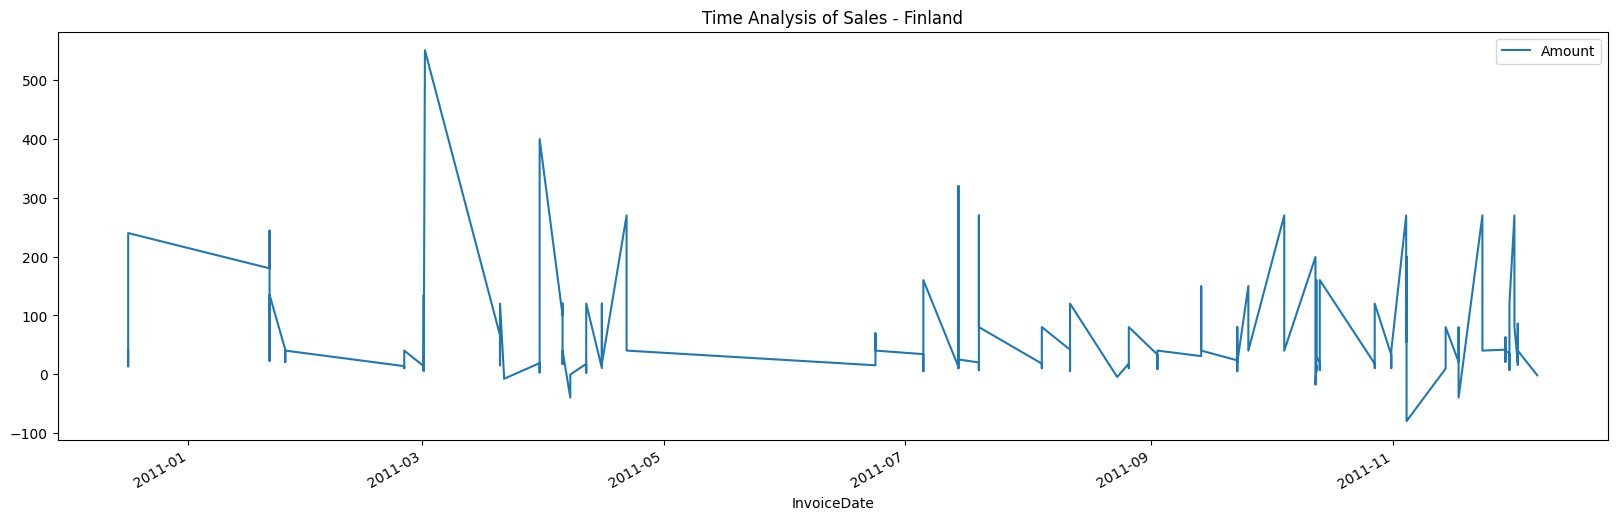

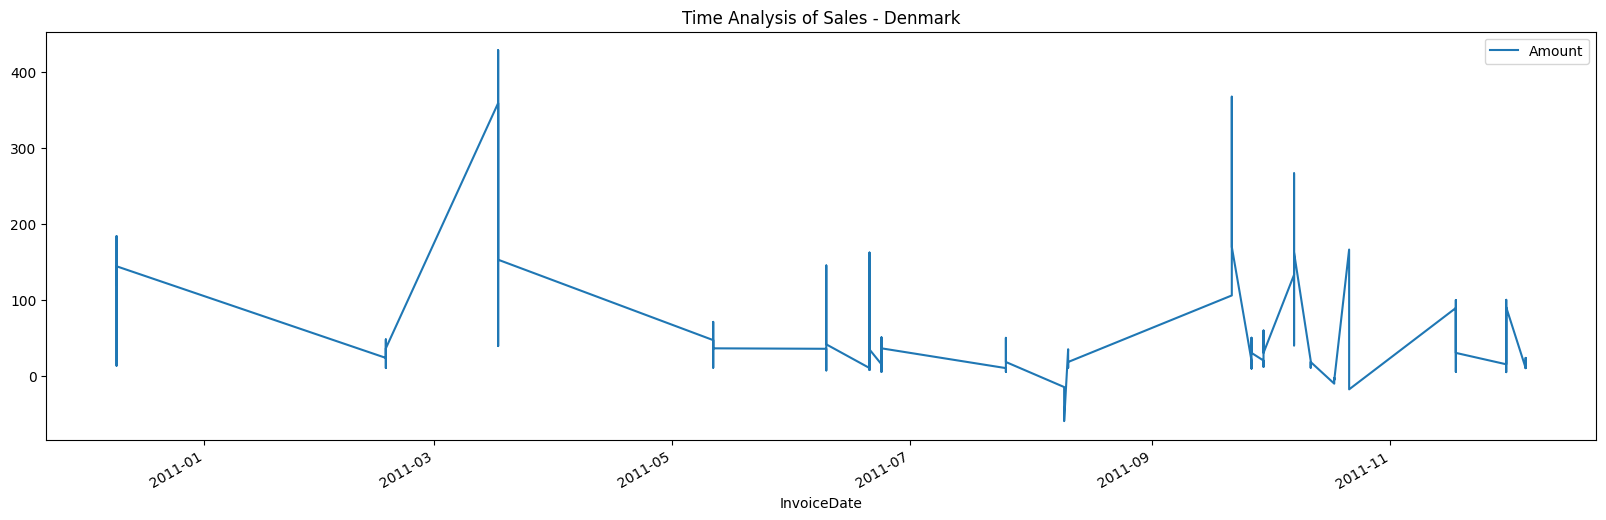

In [ ]:
def time_series(country):
  dataset = data[data['Country'] == country]
  dataset.plot(x = 'InvoiceDate', y = 'Amount')
  plt.title(f'Time Analysis of Sales - {country}')
  plt.show()

time_series('United Kingdom')
time_series('Germany')
time_series('France')
time_series('Portugal')
time_series('Finland')
time_series('Denmark')

#### mostly sold stocks for the datset

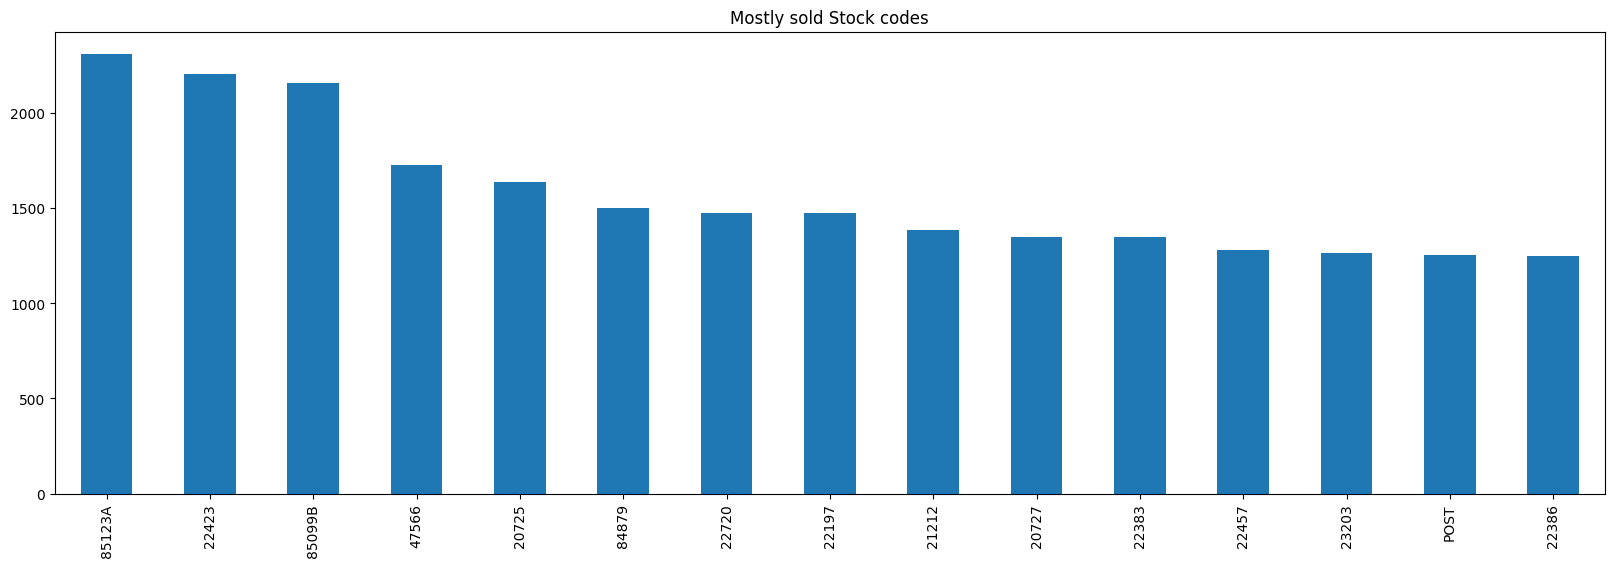

In [ ]:
data['StockCode'].value_counts().head(15).plot.bar()
plt.title('Mostly sold Stock codes')
plt.show()

In [ ]:
data.sort_values(by = 'Amount')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,-168469.60
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.60
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom,-38970.00
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom,-17836.46
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom,-16888.02
...,...,...,...,...,...,...,...,...,...
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60


In [ ]:
data.sort_values(by = 'Quantity')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,-168469.6
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.6
225529,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom,-0.0
225530,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom,-0.0
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom,-280.8
...,...,...,...,...,...,...,...,...,...
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom,1008.0
74614,542504,37413,NaN,5568,2011-01-28 12:03:00,0.00,NaN,United Kingdom,0.0
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom,0.0
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6


In [ ]:
data.sort_values(by = 'UnitPrice')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06
40984,539750,22652,TRAVEL SEWING KIT,1,2010-12-21 15:40:00,0.00,NaN,United Kingdom,0.00
52217,540696,84562A,NaN,1,2011-01-11 09:14:00,0.00,NaN,United Kingdom,0.00
52262,540699,POST,NaN,1000,2011-01-11 09:32:00,0.00,NaN,United Kingdom,0.00
...,...,...,...,...,...,...,...,...,...
16356,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,NaN,United Kingdom,-13541.33
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,NaN,United Kingdom,-16453.71
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom,-16888.02
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom,-17836.46


In [ ]:
data.sort_values(by = 'CustomerID')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.60
286628,562032,21578,WOODLAND DESIGN COTTON TOTE BAG,6,2011-08-02 08:48:00,2.25,12347.0,Iceland,13.50
72263,542237,47559B,TEA TIME OVEN GLOVE,10,2011-01-26 14:30:00,1.25,12347.0,Iceland,12.50
72264,542237,21154,RED RETROSPOT OVEN GLOVE,10,2011-01-26 14:30:00,1.25,12347.0,Iceland,12.50
...,...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom,20.65
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom,16.52
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom,4.96
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom,10.79


###Removing the duplicates and missing values from daraset
###Dropping the rows that has no CustomerID

In [ ]:
print('shape of the dataset before dropping empty instances',data.shape)
data.drop_duplicates(inplace=True)
data.dropna(inplace=True)
data = data[data['CustomerID'].notna()]
print('shape of the dataset after dropping empty instances',data.shape)
print(data.isnull().sum())
data.describe().T

shape of the dataset before dropping empty instances (541909, 9)
shape of the dataset after dropping empty instances (401604, 9)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Amount         0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Quantity,401604.0,12.183273,250.283037,-80995.0,2.00,5.00,12.00,80995.0
UnitPrice,401604.0,3.474064,69.764035,0.0,1.25,1.95,3.75,38970.0
CustomerID,401604.0,15281.160818,1714.006089,12346.0,13939.00,15145.00,16784.00,18287.0
Amount,401604.0,20.613638,430.352218,-168469.6,4.25,11.70,19.80,168469.6


###Dropping the rows that has negative entries

In [ ]:
print('shape of the dataset before dropping negative entries',data.shape)
data=data[(data.Quantity>=0)]
print('shape of the dataset after dropping negative entries',data.shape)
data.describe().T

shape of the dataset before dropping negative entries (401604, 9)
shape of the dataset after dropping negative entries (392732, 9)


,count,mean,std,min,25%,50%,75%,max
Quantity,392732.0,13.153718,181.588420,1.0,2.00,6.00,12.00,80995.00
UnitPrice,392732.0,3.125596,22.240725,0.0,1.25,1.95,3.75,8142.75
CustomerID,392732.0,15287.734822,1713.567773,12346.0,13955.00,15150.00,16791.00,18287.00
Amount,392732.0,22.629195,311.083465,0.0,4.95,12.39,19.80,168469.60


###Dropping the rows that has -ve or 0 Unitprize and the cancelled Transactions

In [ ]:
data=data[(data.UnitPrice>0)]
print('shape of the dataset after dropping negative entries',data.shape)
data.describe().T

shape of the dataset after dropping negative entries (392692, 9)


,count,mean,std,min,25%,50%,75%,max
Quantity,392692.0,13.119702,180.492832,1.000,2.00,6.00,12.00,80995.00
UnitPrice,392692.0,3.125914,22.241836,0.001,1.25,1.95,3.75,8142.75
CustomerID,392692.0,15287.843865,1713.539549,12346.000,13955.00,15150.00,16791.00,18287.00
Amount,392692.0,22.631500,311.099224,0.001,4.95,12.45,19.80,168469.60


In [ ]:
data.nunique()

InvoiceNo      18532
StockCode       3665
Description     3877
Quantity         301
InvoiceDate    17282
UnitPrice        440
CustomerID      4338
Country           37
Amount          2939
dtype: int64


#### checking the different values for country in the dataset

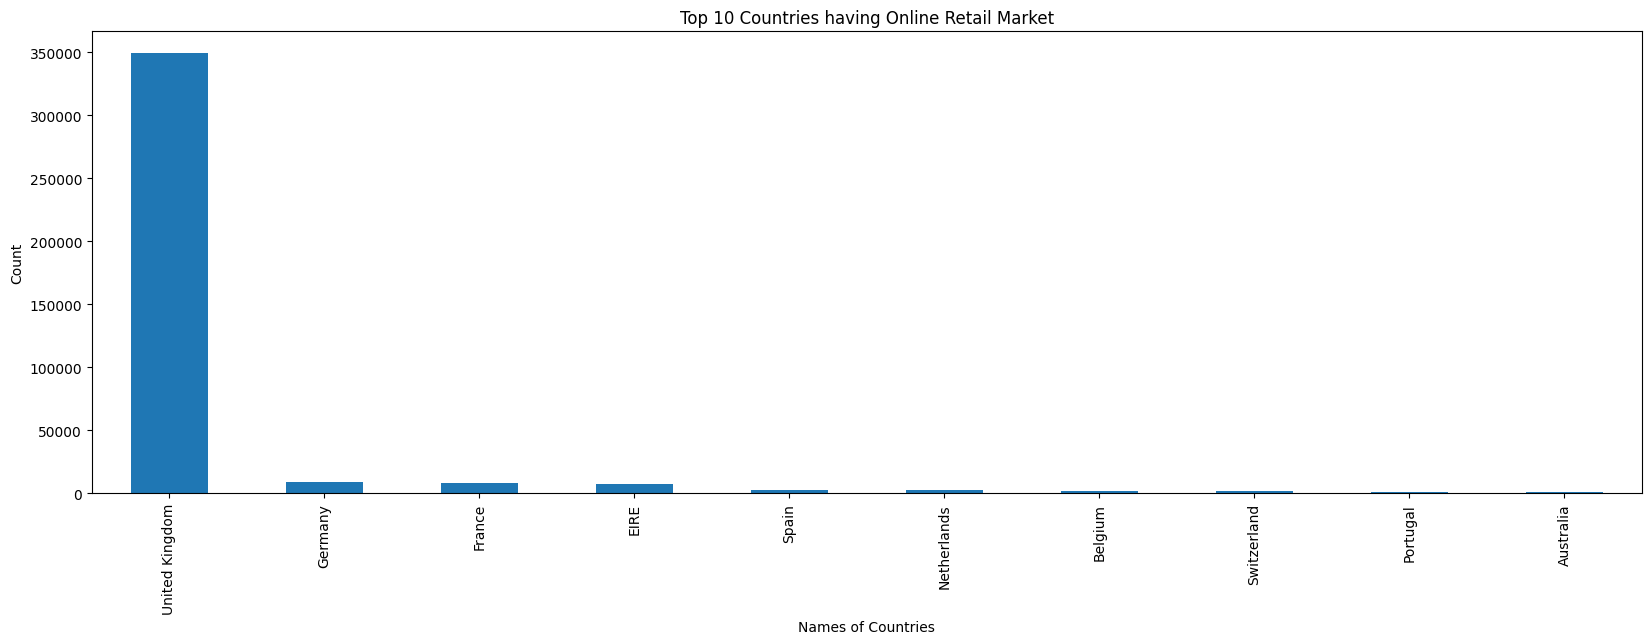

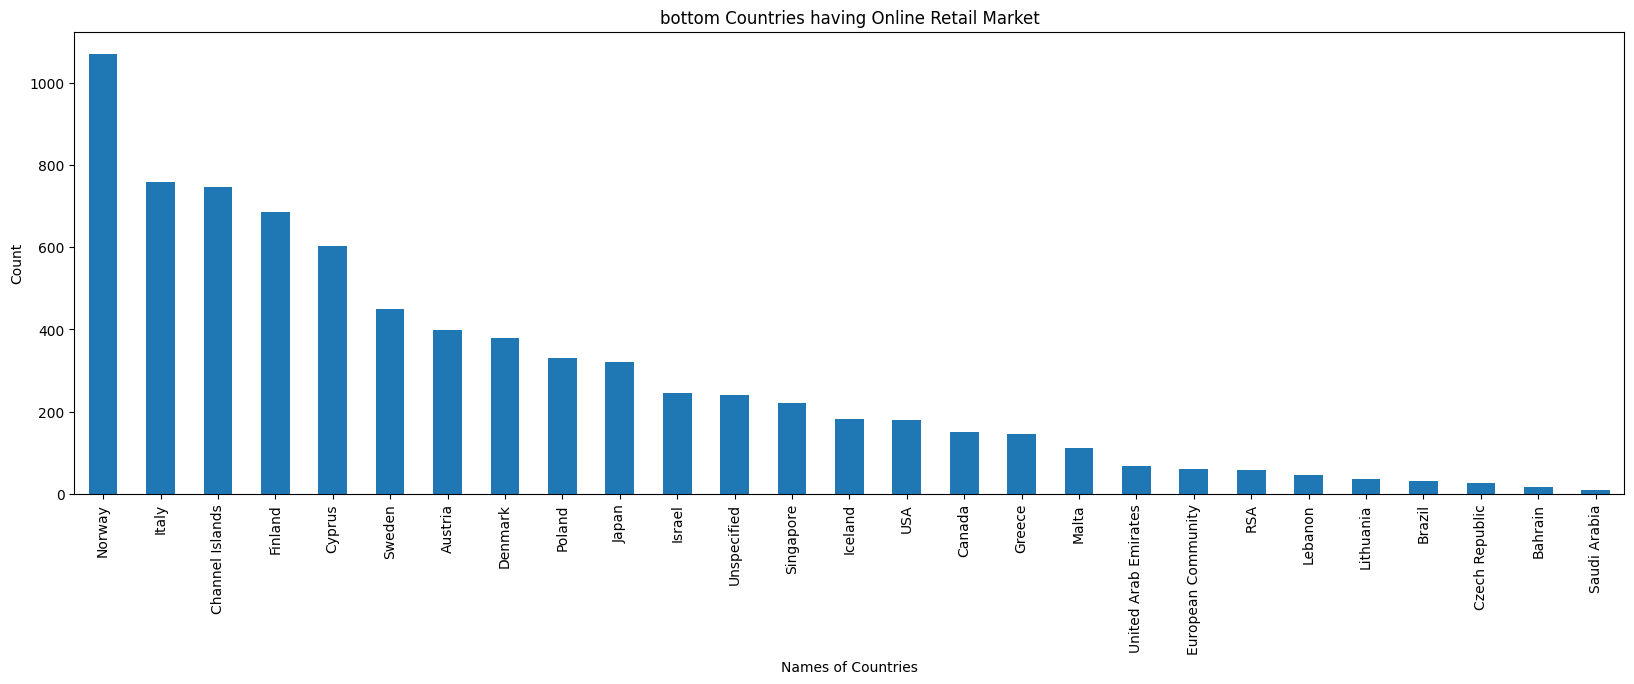

In [ ]:
data['Country'].value_counts().head(10).plot.bar()
plt.title('Top 10 Countries having Online Retail Market')
plt.xlabel('Names of Countries')
plt.ylabel('Count')
plt.show()

data['Country'].value_counts().tail(27).plot.bar()
plt.title('bottom Countries having Online Retail Market')
plt.xlabel('Names of Countries')
plt.ylabel('Count')
plt.show()

###Creating the RFM model (Recency, Frequency,Monetary value)

In [ ]:
reference_date=data.InvoiceDate.max()
reference_date=reference_date+datetime.timedelta(days=1)
print(data.InvoiceDate.max(),data.InvoiceDate.min())
print("reference_date",reference_date)
data

2011-12-09 12:50:00 2010-12-01 08:26:00
reference_date 2011-12-10 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [ ]:
data['days_since_last_purchase']=reference_date-data.InvoiceDate
data['days_since_last_purchase_num']=data['days_since_last_purchase'].astype('timedelta64[D]')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,days_since_last_purchase,days_since_last_purchase_num
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,374 days 04:24:00,374.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,374 days 04:24:00,374.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,374 days 04:24:00,374.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,374 days 04:24:00,374.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,374 days 04:24:00,374.0


In [ ]:
customer_history_df=data.groupby('CustomerID').min().reset_index()[['CustomerID', 'days_since_last_purchase_num']]
customer_history_df.rename(columns={'days_since_last_purchase_num':'Recency'}, inplace=True)
print(customer_history_df.describe())
customer_history_df.head()

         CustomerID      Recency
count   4338.000000  4338.000000
mean   15300.408022    92.536422
std     1721.808492   100.014169
min    12346.000000     1.000000
25%    13813.250000    18.000000
50%    15299.500000    51.000000
75%    16778.750000   142.000000
max    18287.000000   374.000000


,CustomerID,Recency
0,12346.0,326.0
1,12347.0,2.0
2,12348.0,75.0
3,12349.0,19.0
4,12350.0,310.0


Distribution of customer recency

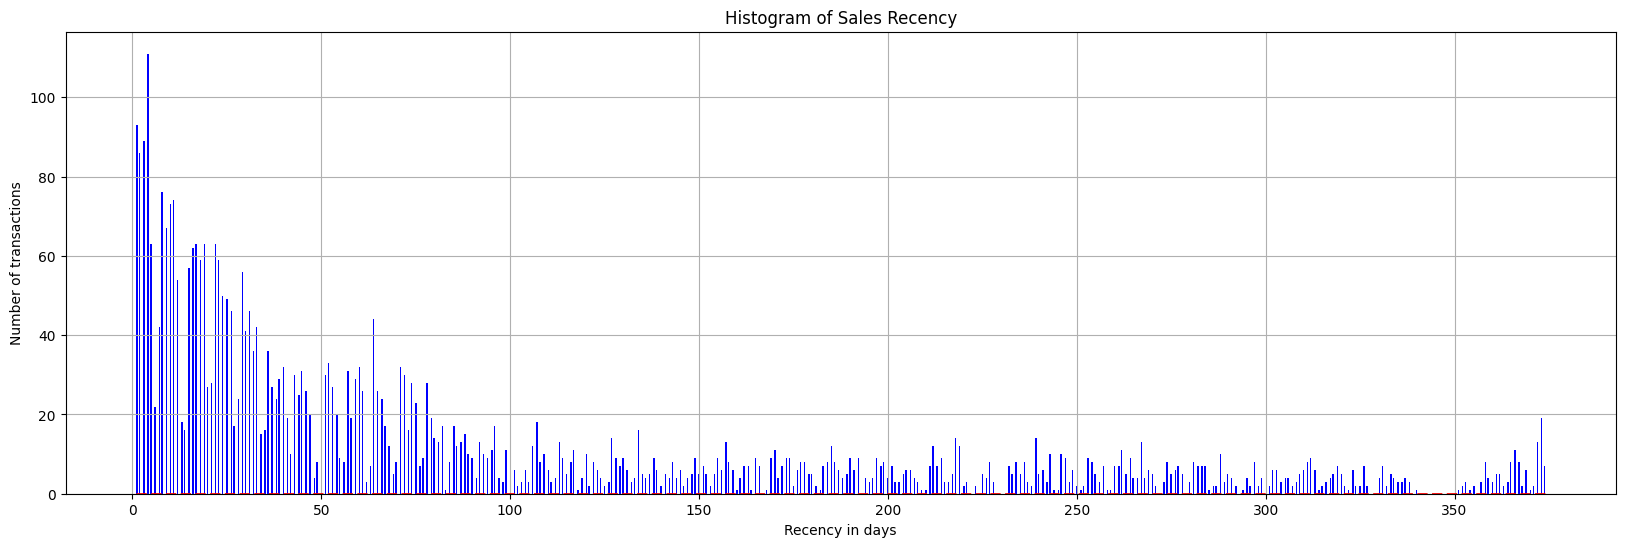

In [ ]:
x=customer_history_df.Recency
mu=np.mean(x)
sigma=math.sqrt(np.var(x))
n,bins,patches=plt.hist(x,1000,facecolor='blue')
# Add a best fit line
y=scipy.stats.norm.pdf(bins,mu,sigma)
l=plt.plot(bins,y,'r--',lw=2)

plt.xlabel('Recency in days')
plt.ylabel('Number of transactions')
plt.title('Histogram of Sales Recency')
plt.grid(True)
plt.show()

In [ ]:
customer_monetary_val=data[['CustomerID','Amount']].groupby('CustomerID').sum().reset_index()
customer_history_df=customer_history_df.merge(customer_monetary_val,how='outer')
customer_history_df.Amount=customer_history_df.Amount+0.001
customer_freq=data[['CustomerID','Amount']].groupby('CustomerID').count().reset_index()
customer_freq.rename(columns={'Amount':'Frequency'},inplace=True)
customer_history_df=customer_history_df.merge(customer_freq,how='outer')

customer_history_df=pd.DataFrame(customer_history_df,columns=['CustomerID','Recency','Amount','Frequency'])
customer_history_df.head()

,CustomerID,Recency,Amount,Frequency
0,12346.0,326.0,77183.601,1
1,12347.0,2.0,4310.001,182
2,12348.0,75.0,1797.241,31
3,12349.0,19.0,1757.551,73
4,12350.0,310.0,334.401,17


In [ ]:
customer_history_df['r_quartile'] = pd.qcut(customer_history_df['Recency'], 4, ['1','2','3','4'])
customer_history_df['f_quartile'] = pd.qcut(customer_history_df['Frequency'], 4, ['4','3','2','1'])
customer_history_df['m_quartile'] = pd.qcut(customer_history_df['Amount'], 4, ['4','3','2','1'])
customer_history_df['RFM_Segment_Code'] = customer_history_df.r_quartile.astype(str)+ customer_history_df.f_quartile.astype(str) + customer_history_df.m_quartile.astype(str)
customer_history_df['RFM_Score'] = customer_history_df.r_quartile.astype(int)+customer_history_df.f_quartile.astype(int)+customer_history_df.m_quartile.astype(int)
customer_history_df.head()

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score
0,12346.0,326.0,77183.601,1,4,4,1,441,9
1,12347.0,2.0,4310.001,182,1,1,1,111,3
2,12348.0,75.0,1797.241,31,3,3,1,331,7
3,12349.0,19.0,1757.551,73,2,2,1,221,5
4,12350.0,310.0,334.401,17,4,4,3,443,11


In [ ]:
customer_history_df.sort_values(by = 'Recency')

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score
1661,14606.0,1.0,12076.151,2677,1,1,1,111,3
871,13510.0,1.0,1791.561,115,1,1,1,111,3
1535,14441.0,1.0,1712.891,51,1,2,1,121,4
2913,16322.0,1.0,326.751,37,1,3,3,133,7
1538,14446.0,1.0,1010.351,277,1,1,2,112,4
...,...,...,...,...,...,...,...,...,...
1749,14729.0,374.0,313.491,71,4,2,3,423,9
4108,17968.0,374.0,265.101,81,4,2,4,424,10
4180,18074.0,374.0,489.601,13,4,4,3,443,11
1037,13747.0,374.0,79.601,1,4,4,4,444,12


In [ ]:
customer_history_df.sort_values(by = 'Frequency')

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score
0,12346.0,326.0,77183.601,1,4,4,1,441,9
2442,15668.0,218.0,76.321,1,4,4,4,444,12
2505,15753.0,305.0,79.201,1,4,4,4,444,12
2540,15802.0,143.0,451.421,1,4,4,3,443,11
2558,15823.0,372.0,15.001,1,4,4,4,444,12
...,...,...,...,...,...,...,...,...,...
1661,14606.0,1.0,12076.151,2677,1,1,1,111,3
326,12748.0,1.0,33053.191,4412,1,1,1,111,3
1289,14096.0,4.0,65164.791,5111,1,1,1,111,3
1879,14911.0,1.0,143711.171,5670,1,1,1,111,3


In [ ]:
customer_history_df.sort_values(by = 'Amount')

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score
3217,16738.0,298.0,3.751,1,4,4,4,444,12
1793,14792.0,64.0,6.201,2,3,4,4,344,11
3014,16454.0,45.0,6.901,2,2,4,4,244,10
4098,17956.0,249.0,12.751,1,4,4,4,444,12
3323,16878.0,84.0,13.301,3,3,4,4,344,11
...,...,...,...,...,...,...,...,...,...
1879,14911.0,1.0,143711.171,5670,1,1,1,111,3
3008,16446.0,1.0,168472.501,3,1,4,1,141,6
3728,17450.0,8.0,194390.791,336,1,1,1,111,3
4201,18102.0,1.0,259657.301,431,1,1,1,111,3


In [ ]:
customer_history_df.sort_values(by = 'RFM_Score')

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score
262,12668.0,12.0,3807.151,161,1,1,1,111,3
1482,14367.0,8.0,9227.821,521,1,1,1,111,3
3065,16525.0,2.0,13027.451,183,1,1,1,111,3
3064,16523.0,2.0,9418.471,290,1,1,1,111,3
1033,13742.0,17.0,3107.871,313,1,1,1,111,3
...,...,...,...,...,...,...,...,...,...
2906,16315.0,331.0,226.371,14,4,4,4,444,12
319,12736.0,333.0,234.001,4,4,4,4,444,12
320,12738.0,372.0,155.351,11,4,4,4,444,12
1727,14699.0,214.0,109.131,8,4,4,4,444,12


In [ ]:
customer_history_df['Amt_Rank'] = customer_history_df['Amount'].rank(ascending=0)
customer_history_df.sort_values(by = 'Amt_Rank')

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score,Amt_Rank
1689,14646.0,2.0,280206.021,2076,1,1,1,111,3,1.0
4201,18102.0,1.0,259657.301,431,1,1,1,111,3,2.0
3728,17450.0,8.0,194390.791,336,1,1,1,111,3,3.0
3008,16446.0,1.0,168472.501,3,1,4,1,141,6,4.0
1879,14911.0,1.0,143711.171,5670,1,1,1,111,3,5.0
...,...,...,...,...,...,...,...,...,...,...
3323,16878.0,84.0,13.301,3,3,4,4,344,11,4334.0
4098,17956.0,249.0,12.751,1,4,4,4,444,12,4335.0
3014,16454.0,45.0,6.901,2,2,4,4,244,10,4336.0
1793,14792.0,64.0,6.201,2,3,4,4,344,11,4337.0


###Applying 80-20 rule
Pareto’s rule says 80% of the results come from 20% of the causes.

Similarly, 20% customers contribute to 80% of your total revenue. Let's verify that because that will help us know which customers to focus on when marketing new products.

getting 80% income based on Amount

In [ ]:
print(f"The 80% of total revenue/income is: {customer_history_df['Amount'].sum() * 0.8}")

The 80% of total revenue/income is: 7109770.585600001


getting top 20% customers and income based on Amount they have spent on overall

In [ ]:
top_20_num = 4338 *0.2
top20_inc = customer_history_df[customer_history_df['Amt_Rank'] <= int(top_20_num)]['Amount'].sum()
print(f"The total revenue/income by top 20% customers is: {top20_inc}")


The total revenue/income by top 20% customers is: 6635246.178


The unique customers of the retailer having customer ID and their percentage of orders by top 10 orders.

In [ ]:
((data.CustomerID.value_counts()/sum(data.CustomerID.value_counts())*100).head(25).cumsum()).reset_index()

,index,CustomerID
0,17841.0,1.954713
1,14911.0,3.398592
2,14096.0,4.700121
3,12748.0,5.823648
4,14606.0,6.505353
5,15311.0,7.107861
6,14646.0,7.636519
7,13089.0,8.098459
8,13263.0,8.522965
9,14298.0,8.939831


Out of 4372 unique customers, the 13 were ordered the 10% of the total sales of retailer based on cumulative sum.

#customer segmentation
#### visualising the customer segmentations based on RFM Scores

[Text(0, 0, '450'),
 Text(0, 0, '387'),
 Text(0, 0, '426'),
 Text(0, 0, '414'),
 Text(0, 0, '454'),
 Text(0, 0, '463'),
 Text(0, 0, '457'),
 Text(0, 0, '518'),
 Text(0, 0, '388'),
 Text(0, 0, '381')]

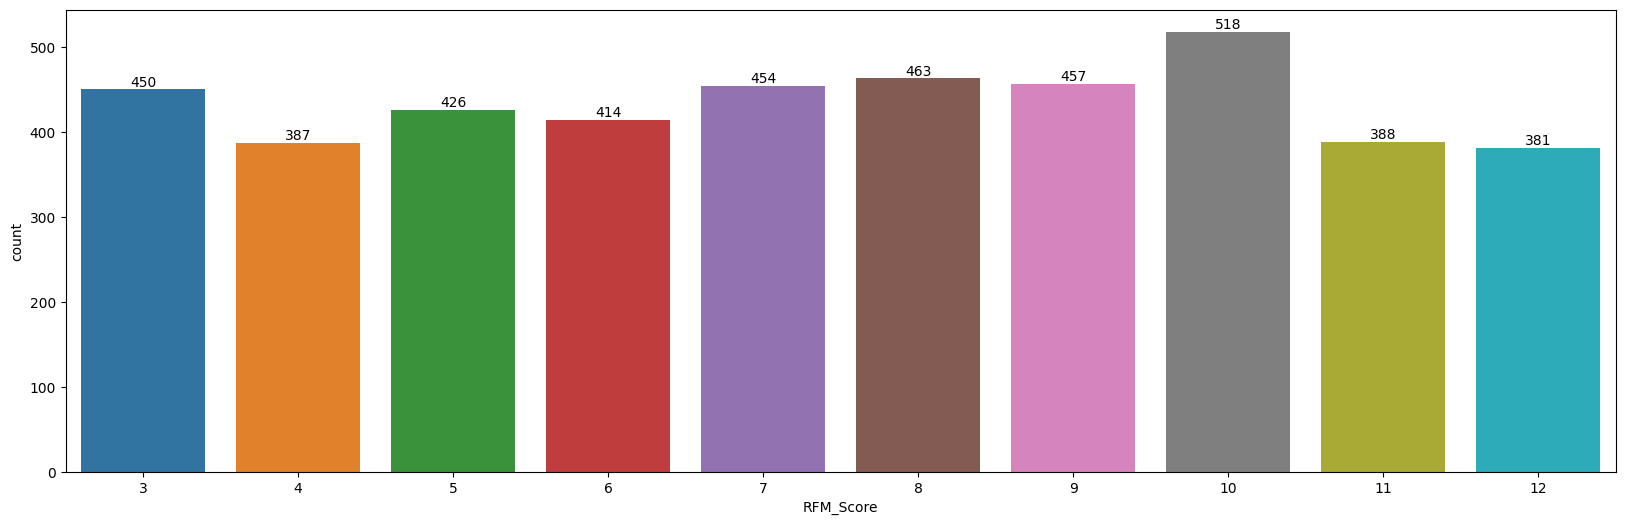

In [ ]:
snp=sns.countplot(x=customer_history_df.RFM_Score)
snp.bar_label(snp.containers[0])

In [ ]:
customer_history_df.sort_values(by = 'Amount')

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score,Amt_Rank
3217,16738.0,298.0,3.751,1,4,4,4,444,12,4338.0
1793,14792.0,64.0,6.201,2,3,4,4,344,11,4337.0
3014,16454.0,45.0,6.901,2,2,4,4,244,10,4336.0
4098,17956.0,249.0,12.751,1,4,4,4,444,12,4335.0
3323,16878.0,84.0,13.301,3,3,4,4,344,11,4334.0
...,...,...,...,...,...,...,...,...,...,...
1879,14911.0,1.0,143711.171,5670,1,1,1,111,3,5.0
3008,16446.0,1.0,168472.501,3,1,4,1,141,6,4.0
3728,17450.0,8.0,194390.791,336,1,1,1,111,3,3.0
4201,18102.0,1.0,259657.301,431,1,1,1,111,3,2.0


In [ ]:
customer_history_df

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score,Amt_Rank
0,12346.0,326.0,77183.601,1,4,4,1,441,9,10.0
1,12347.0,2.0,4310.001,182,1,1,1,111,3,335.0
2,12348.0,75.0,1797.241,31,3,3,1,331,7,1004.0
3,12349.0,19.0,1757.551,73,2,2,1,221,5,1027.0
4,12350.0,310.0,334.401,17,4,4,3,443,11,3097.0
...,...,...,...,...,...,...,...,...,...,...
4333,18280.0,278.0,180.601,10,4,4,4,444,12,3768.0
4334,18281.0,181.0,80.821,7,4,4,4,444,12,4235.0
4335,18282.0,8.0,178.051,12,1,4,4,144,9,3788.0
4336,18283.0,4.0,2045.531,721,1,1,1,111,3,874.0


In [ ]:
customer_history_df['Customer_Class']=customer_history_df.RFM_Score
for i in range(len(customer_history_df.RFM_Score)):
  if(customer_history_df.RFM_Segment_Code[i]=='212' or customer_history_df.RFM_Segment_Code[i]=='211' or customer_history_df.RFM_Segment_Code[i]=='213'):
    customer_history_df.Customer_Class[i] = 'Regular'
  elif(customer_history_df.RFM_Score[i]==3):
    customer_history_df.Customer_Class[i] = 'Best'
  elif(customer_history_df.m_quartile[i]=='1'):
    customer_history_df.Customer_Class[i] = 'Big_Spenders'
  elif(customer_history_df.RFM_Score[i]==4 or customer_history_df.RFM_Score[i]==5 or customer_history_df.RFM_Score[i]==6):
    customer_history_df.Customer_Class[i] = 'Loyal'
  elif(customer_history_df.RFM_Segment_Code[i]=='444'):
    customer_history_df.Customer_Class[i] = 'Lost'
  elif(customer_history_df.RFM_Segment_Code[i]=='434'):
    customer_history_df.Customer_Class[i] = 'Lost_Cheap'
  elif(customer_history_df.RFM_Segment_Code[i]=='344' or (customer_history_df.f_quartile[i]=='4' and customer_history_df.r_quartile[i]=='4')):
    customer_history_df.Customer_Class[i] = 'Almost_Lost'
  elif(customer_history_df.f_quartile[i]>customer_history_df.r_quartile[i]):
    customer_history_df.Customer_Class[i] = 'NEW'
  elif(customer_history_df.RFM_Score[i]==8 or customer_history_df.RFM_Score[i]==9):
    customer_history_df.Customer_Class[i] = 'May Loose'
  else:
    customer_history_df.Customer_Class[i] = 'Non-Regular'

customer_history_df

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score,Amt_Rank,Customer_Class
0,12346.0,326.0,77183.601,1,4,4,1,441,9,10.0,Big_Spenders
1,12347.0,2.0,4310.001,182,1,1,1,111,3,335.0,Best
2,12348.0,75.0,1797.241,31,3,3,1,331,7,1004.0,Big_Spenders
3,12349.0,19.0,1757.551,73,2,2,1,221,5,1027.0,Big_Spenders
4,12350.0,310.0,334.401,17,4,4,3,443,11,3097.0,Almost_Lost
...,...,...,...,...,...,...,...,...,...,...,...
4333,18280.0,278.0,180.601,10,4,4,4,444,12,3768.0,Lost
4334,18281.0,181.0,80.821,7,4,4,4,444,12,4235.0,Lost
4335,18282.0,8.0,178.051,12,1,4,4,144,9,3788.0,NEW
4336,18283.0,4.0,2045.531,721,1,1,1,111,3,874.0,Best


In [ ]:
customer_history_df[customer_history_df.Customer_Class=='Lost']

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score,Amt_Rank,Customer_Class
6,12353.0,204.0,89.001,4,4,4,4,444,12,4223.0,Lost
14,12361.0,287.0,189.901,10,4,4,4,444,12,3731.0,Lost
43,12401.0,303.0,84.301,5,4,4,4,444,12,4231.0,Lost
44,12402.0,323.0,225.601,11,4,4,4,444,12,3564.0,Lost
77,12441.0,367.0,173.551,11,4,4,4,444,12,3808.0,Lost
...,...,...,...,...,...,...,...,...,...,...,...
4292,18224.0,264.0,158.951,10,4,4,4,444,12,3880.0,Lost
4295,18227.0,218.0,93.751,5,4,4,4,444,12,4201.0,Lost
4325,18269.0,366.0,168.601,7,4,4,4,444,12,3832.0,Lost
4333,18280.0,278.0,180.601,10,4,4,4,444,12,3768.0,Lost


In [ ]:
customer_history_df[customer_history_df.Customer_Class=='Lost_Cheap']

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score,Amt_Rank,Customer_Class
126,12506.0,233.0,73.501,23,4,3,4,434,11,4261.5,Lost_Cheap
180,12573.0,227.0,160.541,28,4,3,4,434,11,3872.0,Lost_Cheap
225,12623.0,276.0,305.101,18,4,3,4,434,11,3263.0,Lost_Cheap
472,12956.0,306.0,108.071,19,4,3,4,434,11,4145.0,Lost_Cheap
637,13187.0,337.0,236.021,37,4,3,4,434,11,3518.0,Lost_Cheap
...,...,...,...,...,...,...,...,...,...,...,...
4178,18072.0,186.0,247.441,18,4,3,4,434,11,3476.0,Lost_Cheap
4210,18114.0,290.0,220.101,28,4,3,4,434,11,3586.0,Lost_Cheap
4214,18119.0,368.0,180.701,29,4,3,4,434,11,3767.0,Lost_Cheap
4275,18203.0,157.0,160.421,19,4,3,4,434,11,3873.0,Lost_Cheap


In [ ]:
customer_history_df[customer_history_df.Customer_Class=='Almost_Lost']

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score,Amt_Rank,Customer_Class
4,12350.0,310.0,334.401,17,4,4,3,443,11,3097.0,Almost_Lost
8,12355.0,214.0,459.401,13,4,4,3,443,11,2674.0,Almost_Lost
23,12373.0,311.0,364.601,14,4,4,3,443,11,2975.0,Almost_Lost
33,12386.0,338.0,401.901,10,4,4,3,443,11,2844.0,Almost_Lost
114,12489.0,336.0,334.931,15,4,4,3,443,11,3093.0,Almost_Lost
...,...,...,...,...,...,...,...,...,...,...,...
4316,18255.0,89.0,103.301,6,3,4,4,344,11,4161.5,Almost_Lost
4321,18262.0,140.0,149.481,13,3,4,4,344,11,3945.0,Almost_Lost
4324,18268.0,134.0,25.501,1,3,4,4,344,11,4326.5,Almost_Lost
4331,18277.0,58.0,110.381,8,3,4,4,344,11,4133.5,Almost_Lost


In [ ]:
customer_history_df[customer_history_df.Customer_Class=='Regular']

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score,Amt_Rank,Customer_Class
10,12357.0,33.0,6207.671,131,2,1,1,211,4,202.0,Regular
20,12370.0,51.0,3541.941,166,2,1,1,211,4,456.0,Regular
29,12380.0,22.0,2724.811,104,2,1,1,211,4,624.0,Regular
39,12395.0,19.0,3018.631,156,2,1,1,211,4,550.0,Regular
40,12397.0,36.0,2409.901,126,2,1,1,211,4,731.0,Regular
...,...,...,...,...,...,...,...,...,...,...,...
4181,18075.0,23.0,2611.751,142,2,1,1,211,4,665.0,Regular
4184,18079.0,45.0,3613.151,123,2,1,1,211,4,442.0,Regular
4219,18125.0,30.0,1131.751,192,2,1,2,212,5,1496.0,Regular
4294,18226.0,44.0,5228.051,242,2,1,1,211,4,254.0,Regular


In [ ]:
customer_history_df[customer_history_df.Customer_Class=='Non-Regular']

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score,Amt_Rank,Customer_Class
18,12365.0,291.0,641.381,22,4,3,3,433,10,2237.0,Non-Regular
22,12372.0,72.0,1298.041,52,3,2,2,322,7,1353.0,Non-Regular
36,12391.0,22.0,439.661,93,2,2,3,223,7,2723.0,Non-Regular
37,12393.0,72.0,1582.601,64,3,2,2,322,7,1135.0,Non-Regular
42,12399.0,119.0,1108.651,59,3,2,2,322,7,1522.0,Non-Regular
...,...,...,...,...,...,...,...,...,...,...,...
4286,18218.0,211.0,641.921,20,4,3,3,433,10,2236.0,Non-Regular
4311,18248.0,123.0,804.021,47,3,2,2,322,7,1917.0,Non-Regular
4313,18250.0,310.0,349.271,21,4,3,3,433,10,3039.0,Non-Regular
4315,18252.0,51.0,518.271,94,2,2,3,223,7,2529.0,Non-Regular


In [ ]:
customer_history_df[customer_history_df.Customer_Class=='May Loose']

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score,Amt_Rank,Customer_Class
7,12354.0,232.0,1079.401,58,4,2,2,422,8,1554.0,May Loose
16,12363.0,110.0,552.001,23,3,3,3,333,9,2450.0,May Loose
26,12377.0,315.0,1628.121,77,4,2,2,422,8,1104.0,May Loose
28,12379.0,82.0,852.241,40,3,3,2,332,8,1851.0,May Loose
35,12390.0,80.0,549.841,32,3,3,3,333,9,2455.0,May Loose
...,...,...,...,...,...,...,...,...,...,...,...
4274,18202.0,200.0,1396.991,68,4,2,2,422,8,1264.0,May Loose
4290,18222.0,93.0,443.001,19,3,3,3,333,9,2717.0,May Loose
4296,18228.0,57.0,779.901,30,3,3,2,332,8,1956.0,May Loose
4300,18232.0,82.0,592.971,37,3,3,3,333,9,2365.0,May Loose


In [ ]:
customer_history_df[customer_history_df.Customer_Class=='NEW']

,CustomerID,Recency,Amount,Frequency,r_quartile,f_quartile,m_quartile,RFM_Segment_Code,RFM_Score,Amt_Rank,Customer_Class
19,12367.0,4.0,168.901,11,1,4,4,144,9,3830.0,NEW
24,12374.0,25.0,742.931,33,2,3,2,232,7,2020.0,NEW
25,12375.0,11.0,457.501,17,1,4,3,143,8,2681.0,NEW
32,12384.0,29.0,585.271,27,2,3,3,233,8,2378.0,NEW
45,12403.0,50.0,427.701,5,2,4,3,243,9,2757.0,NEW
...,...,...,...,...,...,...,...,...,...,...,...
4326,18270.0,38.0,283.151,11,2,4,4,244,10,3360.0,NEW
4328,18273.0,2.0,204.001,3,1,4,4,144,9,3661.5,NEW
4329,18274.0,30.0,175.921,11,2,4,4,244,10,3797.0,NEW
4330,18276.0,44.0,335.861,14,2,4,3,243,9,3089.0,NEW


In [ ]:
customer_history_df.Customer_Class.value_counts()

NEW             729
Non-Regular     565
Loyal           551
May Loose       508
Best            450
Big_Spenders    418
Lost            381
Regular         324
Almost_Lost     312
Lost_Cheap      100
Name: Customer_Class, dtype: int64

[Text(0, 0, '418'),
 Text(0, 0, '450'),
 Text(0, 0, '312'),
 Text(0, 0, '381'),
 Text(0, 0, '508'),
 Text(0, 0, '324'),
 Text(0, 0, '551'),
 Text(0, 0, '565'),
 Text(0, 0, '729'),
 Text(0, 0, '100')]

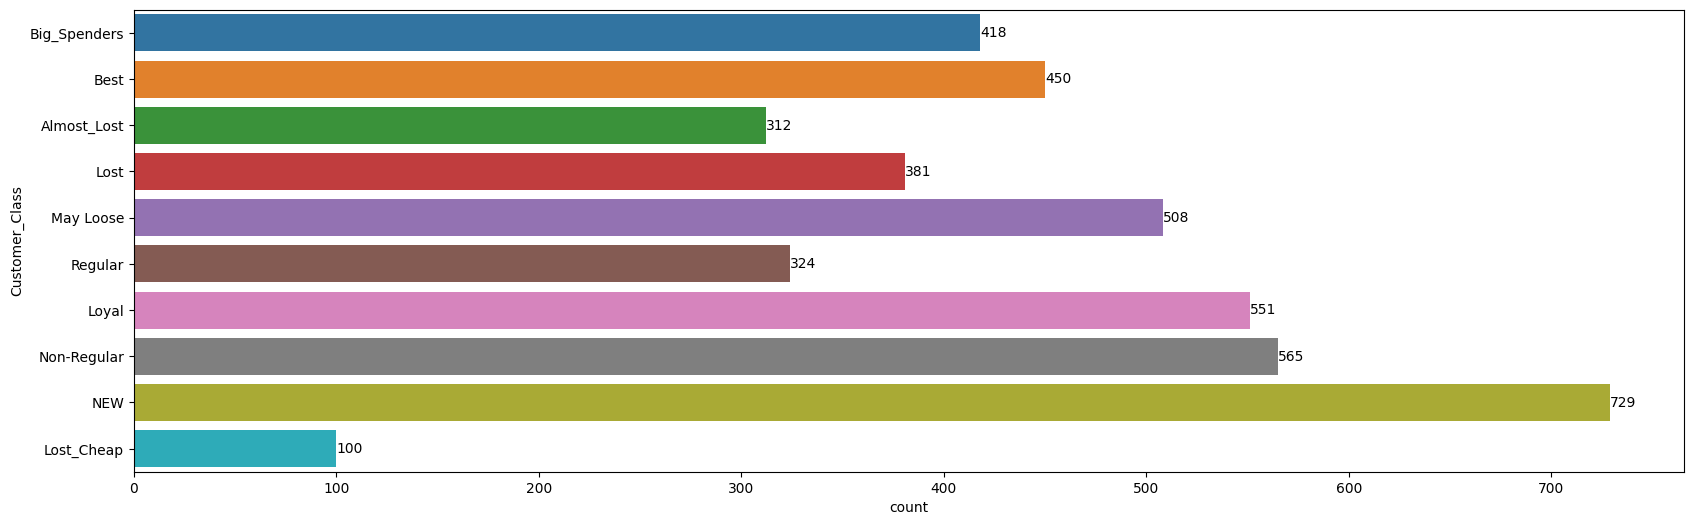

In [ ]:
snp=sns.countplot(y=customer_history_df.Customer_Class)
snp.bar_label(snp.containers[0])

Corr_Matrix for the RFM dataset

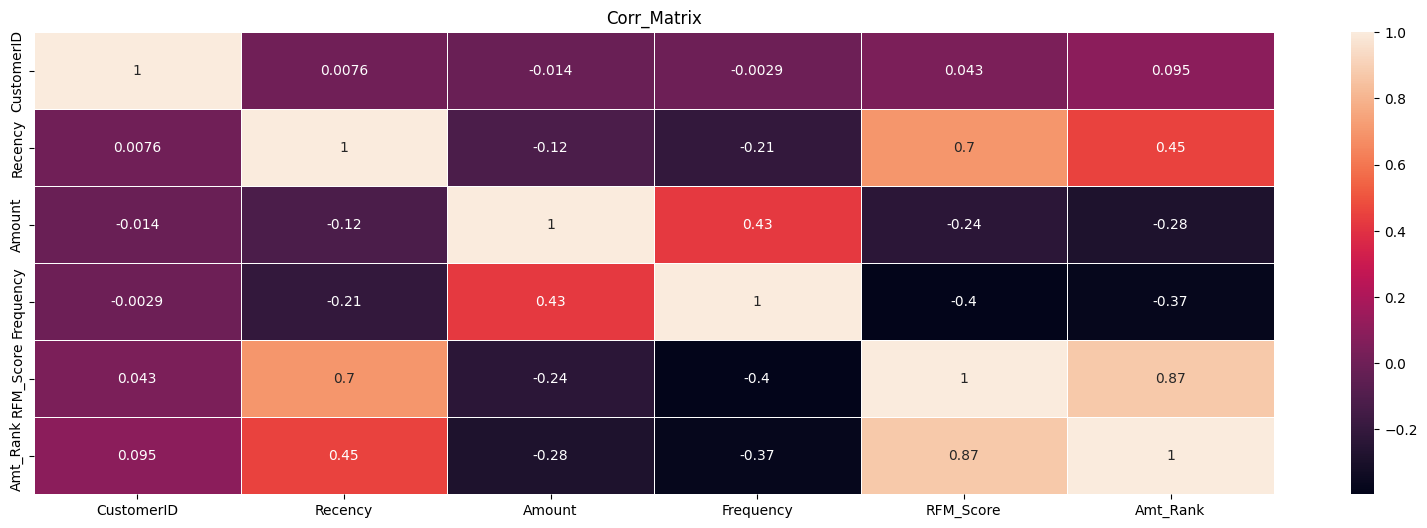

In [ ]:
corr_mat=customer_history_df.corr()
sns.heatmap(corr_mat,annot=True,linewidth=.5)
plt.title('Corr_Matrix')
plt.show()

###Clustering the customers based on the Customer Classes



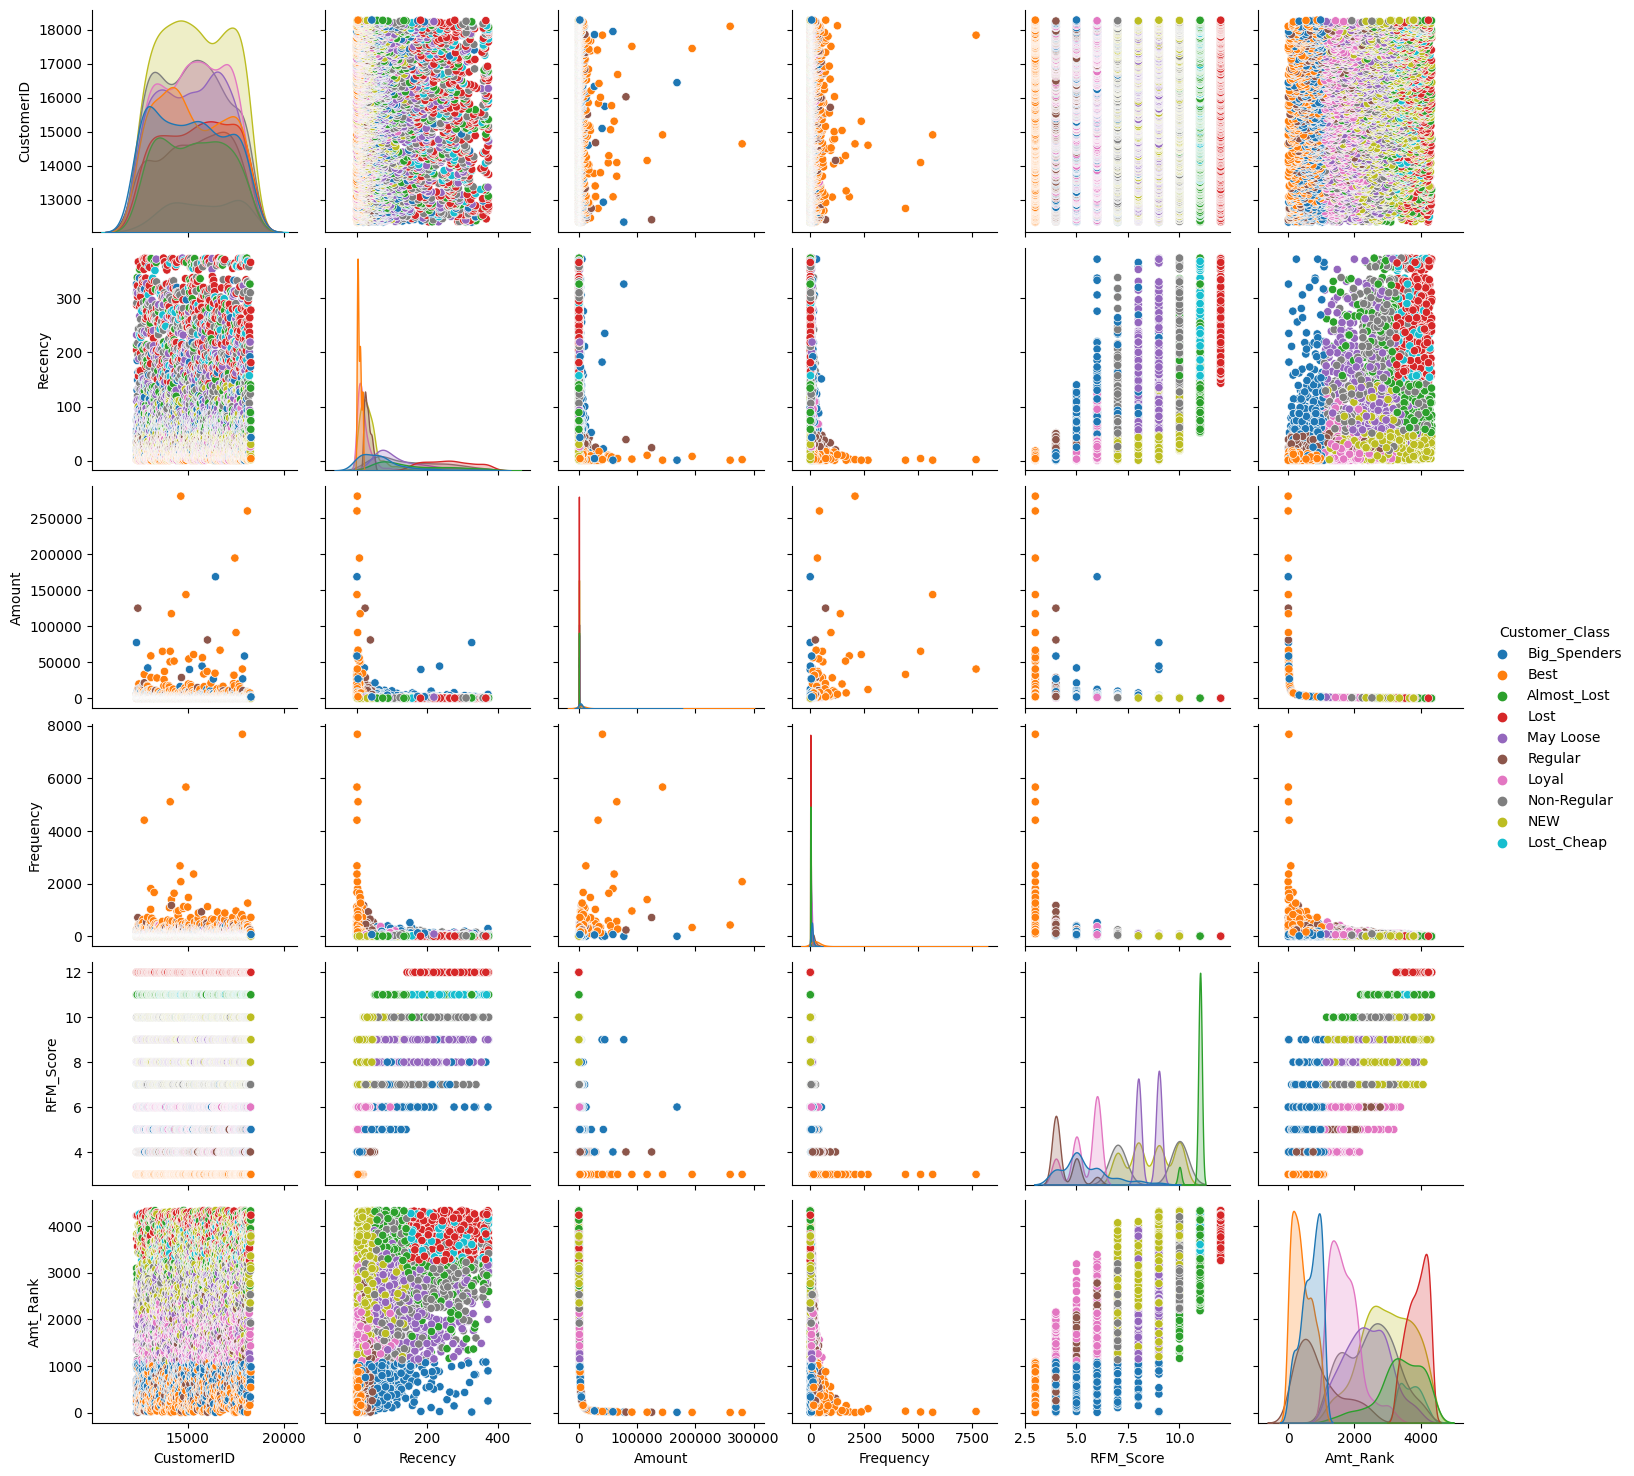

In [ ]:
sns.pairplot(data=customer_history_df, hue='Customer_Class')

###Converting the Catagorial variables into continuous variables using LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
data['Country'] = label_encoder.fit_transform(data['Country'])

#Exploratory Data Analysis
###visualising the distribution of features

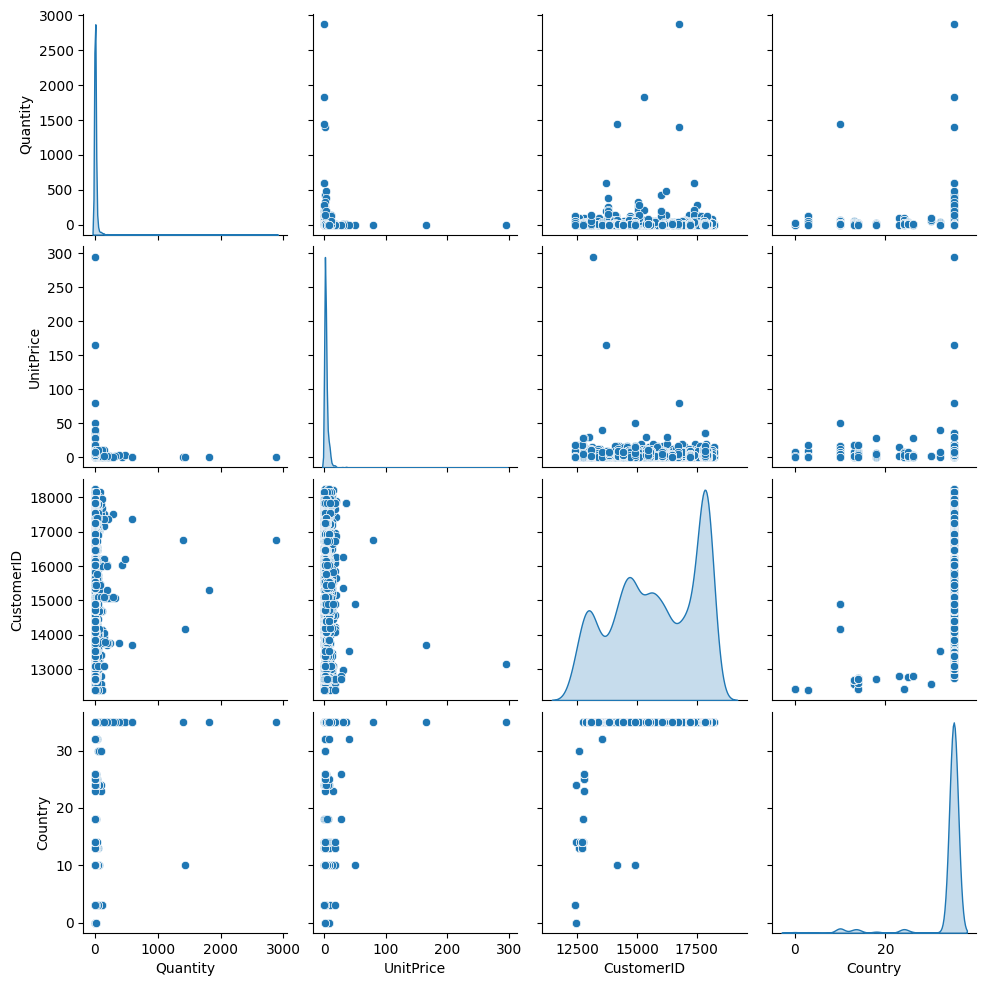

In [ ]:
columns=['Quantity','UnitPrice', 'CustomerID', 'Country']
df =data.head(5000)
sns.pairplot(df[columns],diag_kind="kde")

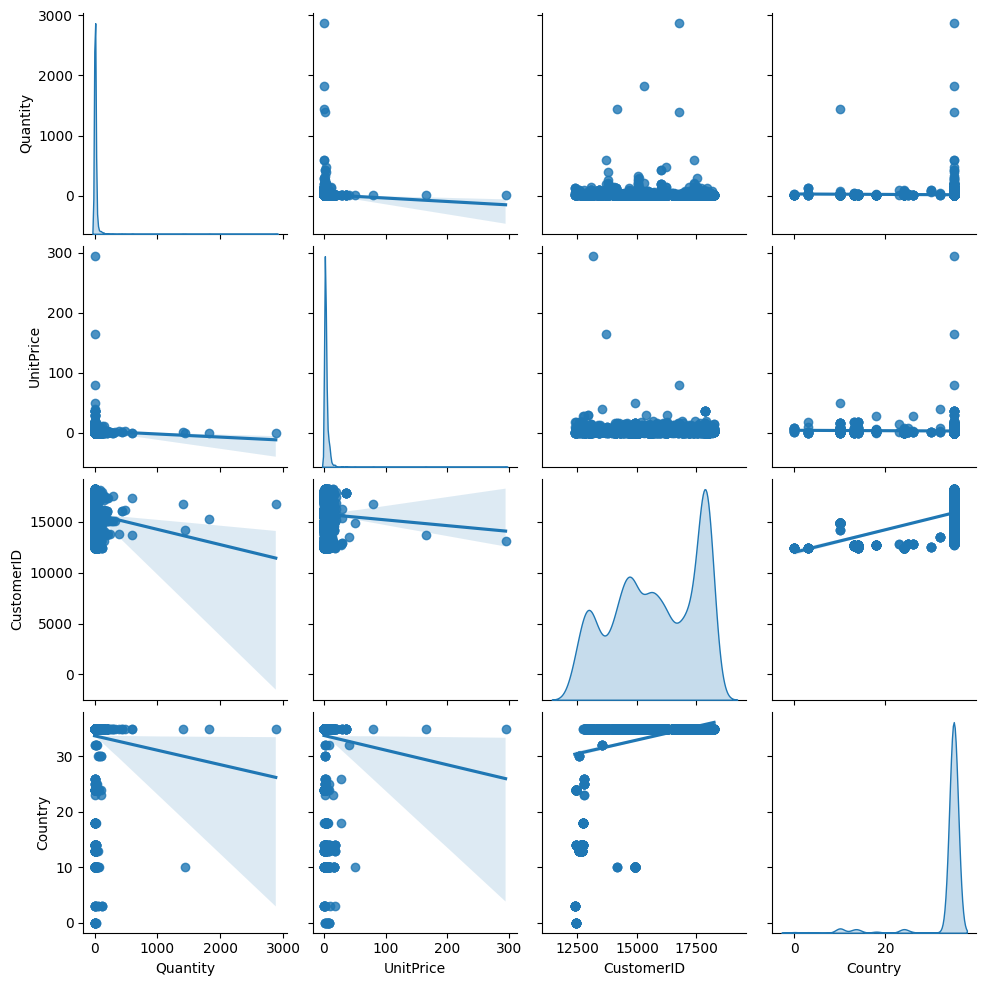

In [ ]:
sns.pairplot(df[columns], diag_kind='kde', kind="reg")

###Covariance and Correlation matrices after encoding on Original Dataset

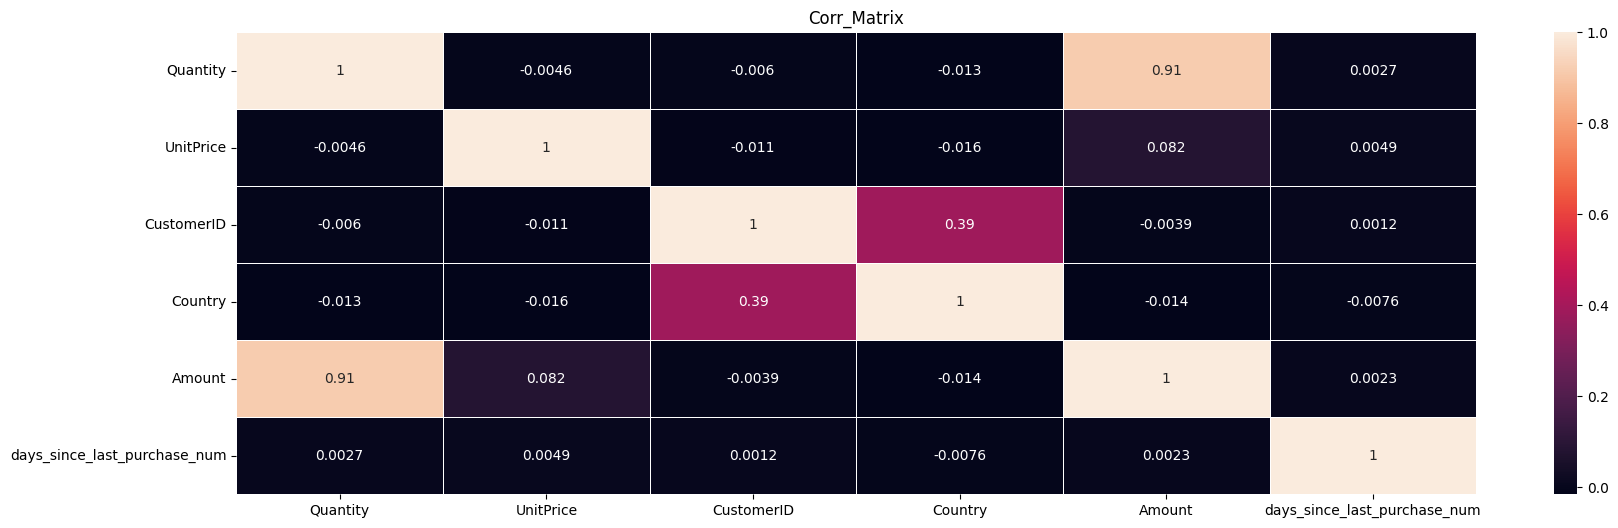

In [ ]:
corr_mat=data.corr()
sns.heatmap(corr_mat,annot=True,linewidth=.5)
plt.title('Corr_Matrix')
plt.show()

###Applying log for better calculations, Scaling and managing outliers

In [ ]:
df_r_log = np.log(customer_history_df['Recency']+0.1)
df_f_log = np.log(customer_history_df['Frequency']+0.1)
df_m_log = np.log(customer_history_df['Amount']+0.1)
customer_log=pd.DataFrame({'Monetary': df_m_log,'Recency': df_r_log,'Frequency': df_f_log})
customer_log['Class']=customer_history_df['Customer_Class']
X = customer_log.values[:,0:2]
Y = customer_log.values[:,3]
X_train, X_rem, Y_train, Y_rem = model_selection.train_test_split(X, Y, train_size=0.7)
X_val, X_test, Y_val, Y_test = model_selection.train_test_split(X_rem, Y_rem, train_size=0.33)
customer_log

,Monetary,Recency,Frequency,Class
0,11.253944,5.787204,0.095310,Big_Spenders
1,8.368717,0.741937,5.204556,Best
2,7.494064,4.318821,3.437208,Big_Spenders
3,7.471734,2.949688,4.291828,Big_Spenders
4,5.812640,5.736895,2.839078,Almost_Lost
...,...,...,...,...
4333,5.196844,5.627981,2.312535,Lost
4334,4.393473,5.199049,1.960095,Lost
4335,5.182632,2.091864,2.493205,NEW
4336,7.623462,1.410987,6.580778,Best


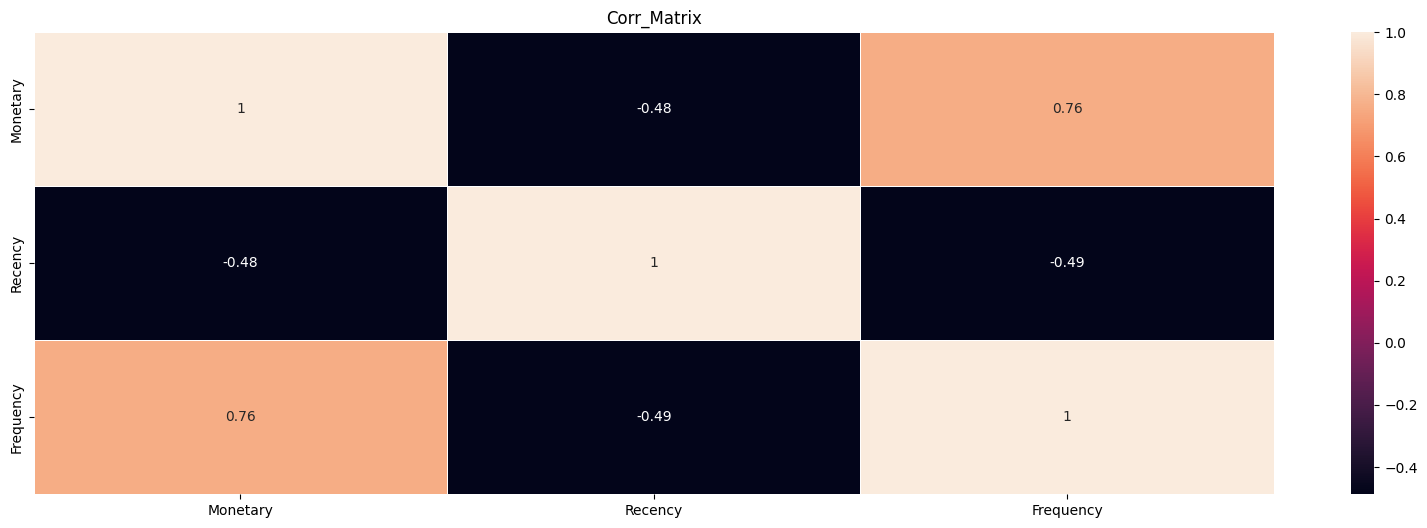

In [ ]:
corr_mat=customer_log.corr()
sns.heatmap(corr_mat,annot=True,linewidth=.5)
plt.title('Corr_Matrix')
plt.show()

##SVM Classifier
####Implementing a SVM for different values of C

In [ ]:
c=0.1
high_val_acc = 0
optm_c=None
while(c<500):
  svm=SVC(kernel='rbf', C = c )
  svm.fit(X_train, Y_train)
  val_acc=svm.score(X_val,Y_val)
  if val_acc > high_val_acc:
        high_val_acc = val_acc
        optm_c = c
  c+=0.5
print("Accuracy score of SVM classifier on validation data is:",round(high_val_acc,7),f'with optm_c = {optm_c}')

Accuracy score of SVM classifier on validation data is: 0.6643357 with optm_c = 223.1


In [ ]:
svm=SVC(kernel='rbf', C = optm_c)
svm.fit(X_train, Y_train)
print("Accuracy score of SVM classifier on test data is:",round(svm.score(X_test,Y_test),7),f'with optm_c = {optm_c}')

Accuracy score of SVM classifier on test data is: 0.696449 with optm_c = 223.1


###KMeans classsifier on RFM dataset

finding the optimal K value for no.of clusters to form

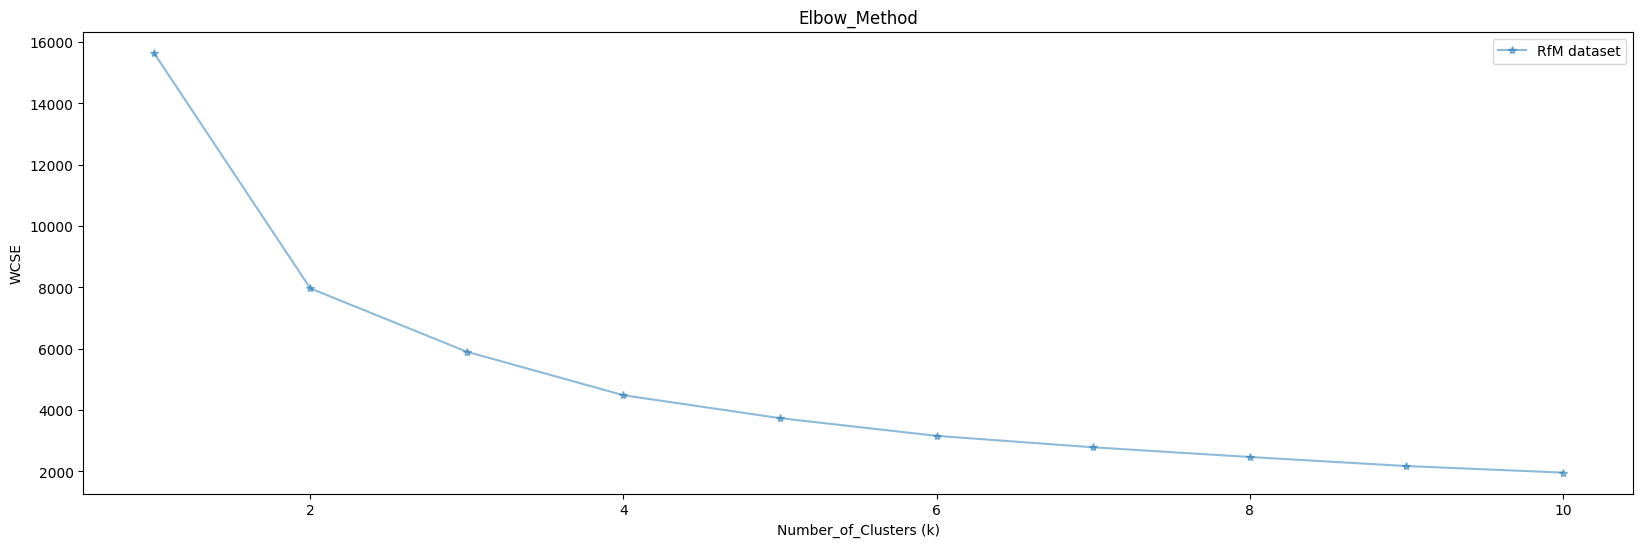

In [ ]:
def opt_k_EM(ds,d_set,m):
  wcse = [] # Within Cluster Sum of Squared Errors (WCSS)
  n = 10
  for i in range(1, n+1):
      kmeans = KMeans(n_clusters = i, init = 'k-means++')
      kmeans.fit(ds)
      wcse.append(kmeans.inertia_)

  plt.plot(np.arange(1 , n+1) , wcse , marker=m , alpha = 0.5, label=f'{d_set}')
  plt.xlabel('Number_of_Clusters (k)')
  plt.ylabel('WCSE')
  plt.title('Elbow_Method')
  plt.legend()

opt_k_EM(customer_log.values[:,0:2],'RfM dataset','*')

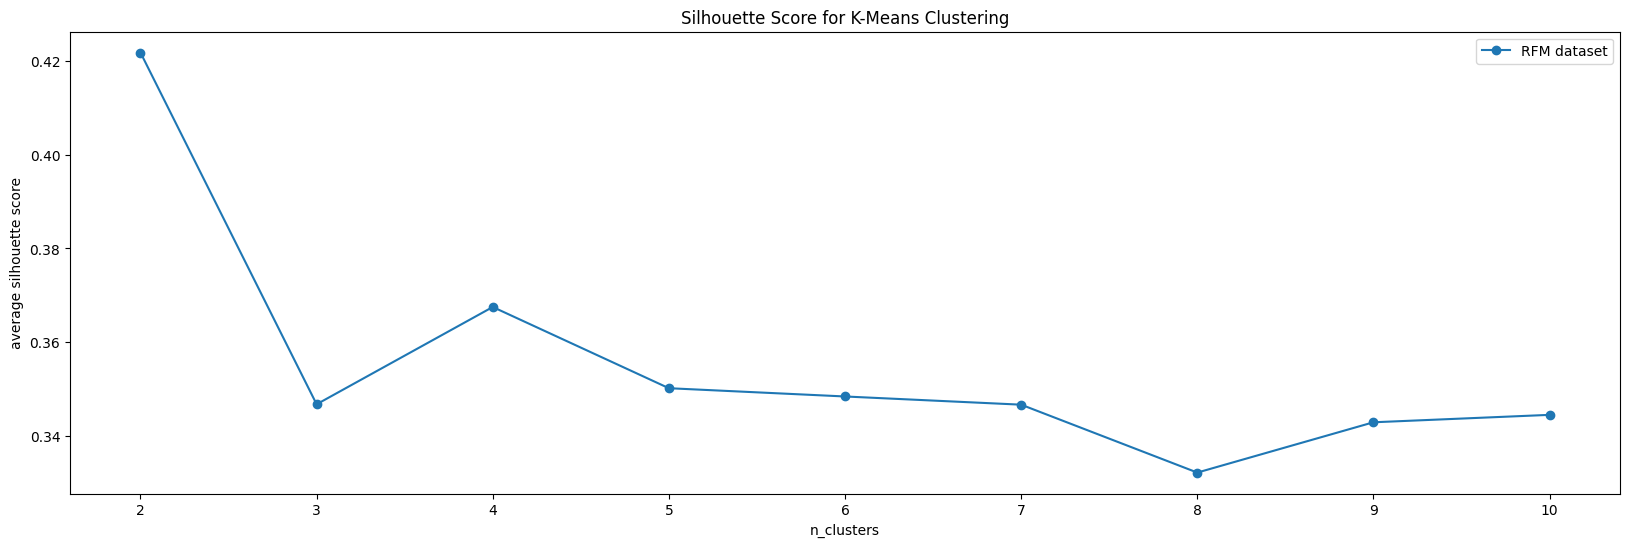

In [ ]:
def opt_K_SS(ds,d_set):
  avg = []
  for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10)
    kmeans.fit(ds)
    # Getting the silhoutte_average for every k value
    silhouette_avg = silhouette_score(ds, kmeans.labels_)
    avg.append(silhouette_avg)
  #plotting the Silhouette Score for K-Means Clustering
  plt.plot(range(2,11),avg,'o-',label=f'{d_set}')
  plt.xlabel("n_clusters")
  plt.title('Silhouette Score for K-Means Clustering')
  plt.ylabel("average silhouette score")
  plt.legend()

opt_K_SS(customer_log.values[:,0:2],'RFM dataset')

In [ ]:
Kmm_model = KMeans(n_clusters = 4)
Kmm_model.fit(customer_log.values[:,0:2])
Kmm_clustrs = Kmm_model.labels_
customer_log['Cluster'] = Kmm_clustrs

Text(0.5, 1.0, 'clusters formed with K-Means')

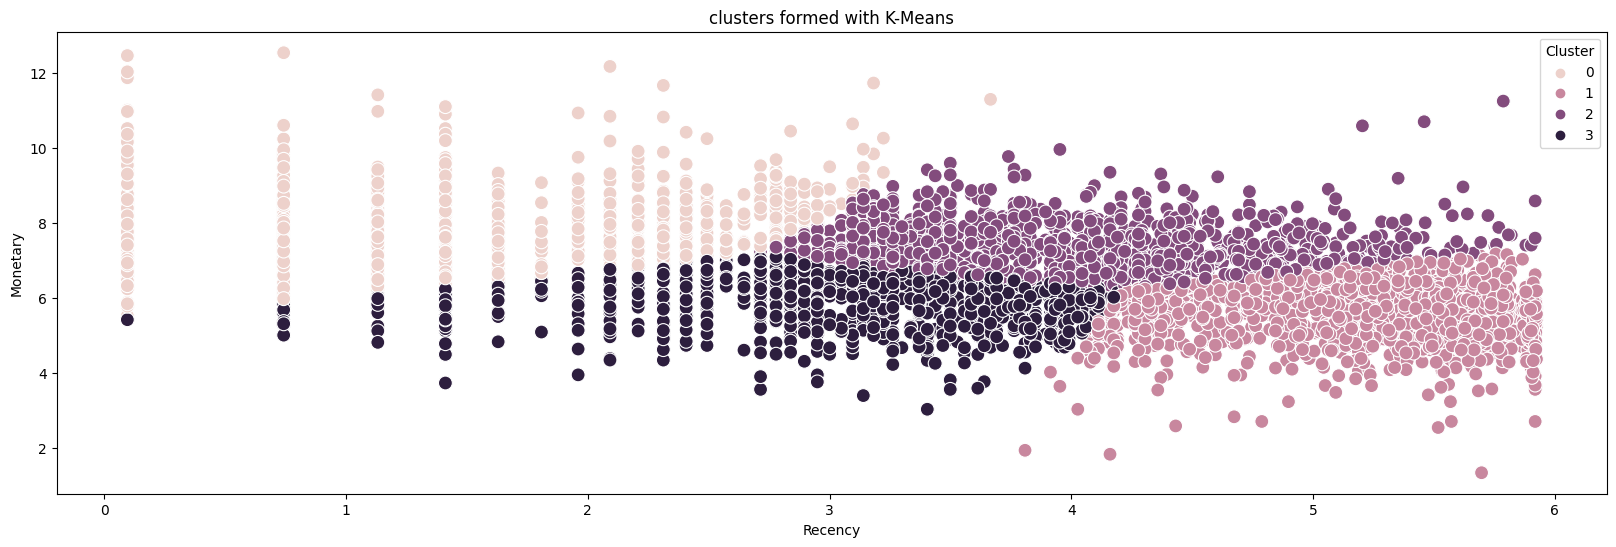

In [ ]:
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=customer_log, s=100)
plt.title('clusters formed with K-Means')

## Feature selection by Applying Principal Component Analysis on Original dataset
####scaling the dataset with min max scaler

In [ ]:
scaler = MinMaxScaler()
data_rescaled = scaler.fit_transform(data[columns])

####finding the optimal number of principal components

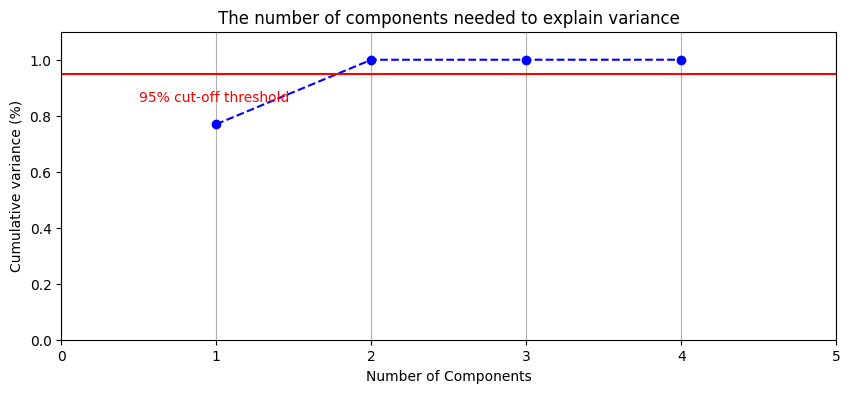

In [ ]:
pca = PCA().fit(data_rescaled)
plt.rcParams["figure.figsize"] = (10,4)

fig, ax = plt.subplots()
xi = np.arange(1, 5, step=1)
y = np.cumsum(pca.explained_variance_ratio_)

plt.ylim(0.0,1.1)
plt.plot(xi, y, marker='o', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, 6, step=1))
plt.ylabel('Cumulative variance (%)')
plt.title('The number of components needed to explain variance')

plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red')

ax.grid(axis='x')
plt.show()

In [ ]:
pca = PCA(n_components=2)
data_red = pca.fit_transform(data_rescaled)
data['PC1'],data['PC2']=data_red[:,0],data_red[:,1]

In [ ]:
data_red=pd.DataFrame(data_red,columns=['PC1','PC2'])
data_red

,PC1,PC2
0,-0.425019,0.094920
1,-0.425019,0.094920
2,-0.425019,0.094920
3,-0.425019,0.094920
4,-0.425019,0.094920
...,...,...
392687,0.604458,0.361237
392688,0.604458,0.361237
392689,0.604458,0.361237
392690,0.604458,0.361237


In [ ]:
sum(pca.explained_variance_ratio_)*100

99.98949851136851

###Visualizing the explained variance ration

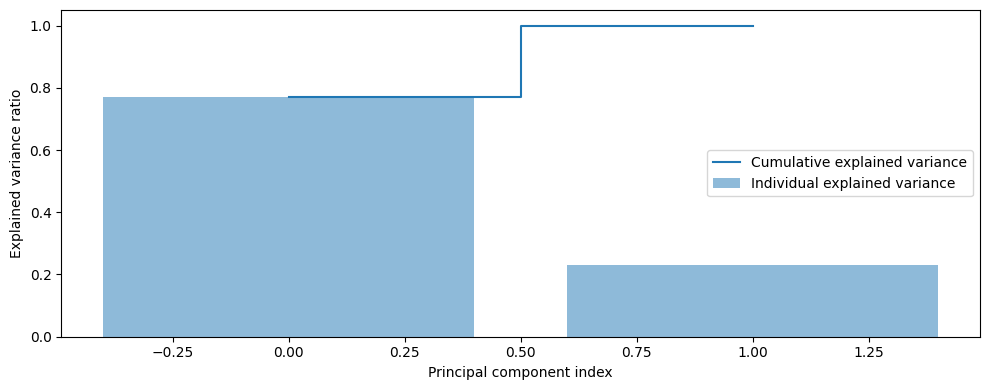

In [ ]:
exp_var_pca=pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

plt.bar(range(0,len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(0,len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid',label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc="center right")
plt.tight_layout()
plt.show()

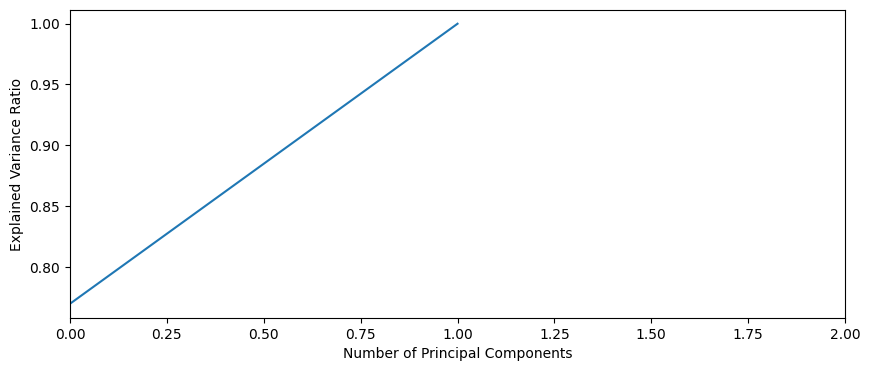

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.xlim(0,2)
plt.show()

Text(0.5, 1.0, 'Reduced dataset with PCA')

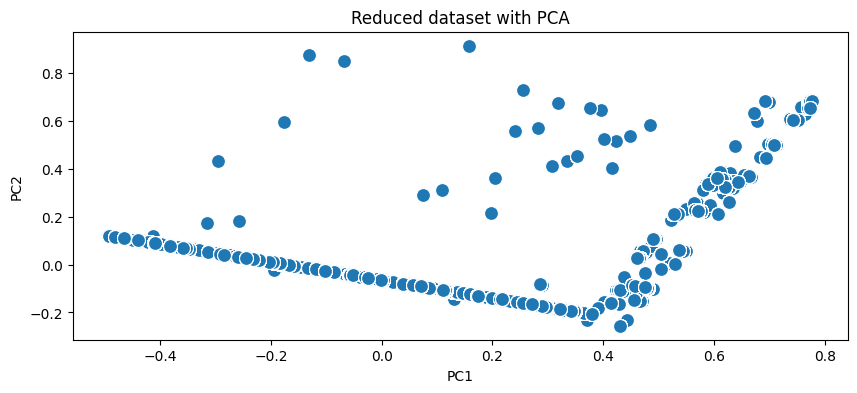

In [ ]:
sns.scatterplot(x='PC1', y='PC2', data=data_red,s=100)
plt.title('Reduced dataset with PCA')

#Making Clusters using K-means

###Elbow Method for finding optimal K value

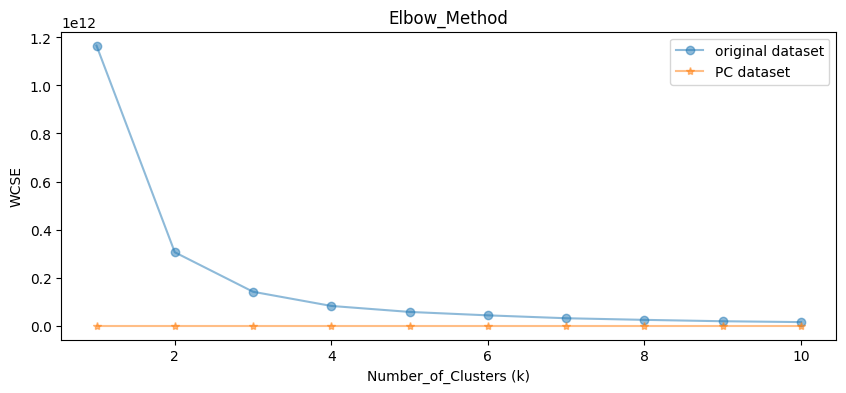

In [ ]:
#finding the optimal K value for no.of clusters to form
def opt_k_EM(ds,d_set,m):
  wcse = [] # Within Cluster Sum of Squared Errors (WCSS)
  n = 10
  for i in range(1, n+1):
      kmeans = KMeans(n_clusters = i, init = 'k-means++')
      kmeans.fit(ds)
      wcse.append(kmeans.inertia_)

  plt.plot(np.arange(1 , n+1) , wcse , marker=m , alpha = 0.5, label=f'{d_set}')
  plt.xlabel('Number_of_Clusters (k)')
  plt.ylabel('WCSE')
  plt.title('Elbow_Method')
  plt.legend()

opt_k_EM(data[columns],'original dataset','o')
opt_k_EM(data_red,'PC dataset','*')

###silhouette_score for finding optimal K value

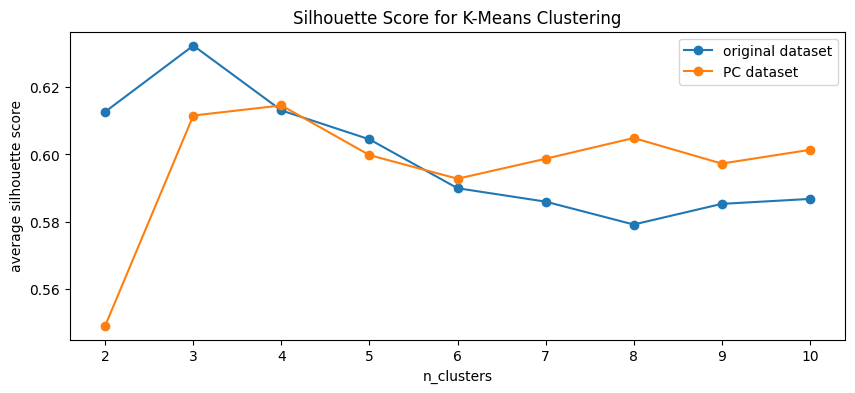

In [ ]:
def opt_K_SS(ds,d_set):
  avg = []
  for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10)
    kmeans.fit(ds.head(30000))
    # Getting the silhoutte_average for every k value
    silhouette_avg = silhouette_score(ds.head(30000), kmeans.labels_)
    avg.append(silhouette_avg)
  #plotting the Silhouette Score for K-Means Clustering
  plt.plot(range(2,11),avg,'o-',label=f'{d_set}')
  plt.xlabel("n_clusters")
  plt.title('Silhouette Score for K-Means Clustering')
  plt.ylabel("average silhouette score")
  plt.legend()

opt_K_SS(data[columns],'original dataset')
opt_K_SS(data_red,'PC dataset')

### Applying K-Means Algorithm with k=3

In [ ]:
Kmm_model = KMeans(n_clusters = 3)
Kmm_model.fit(data[columns])
Kmm_clustrs = Kmm_model.labels_
data['Cluster_KM_OD'] = Kmm_clustrs

In [ ]:
# Evaluate clustering using metrics
print('silhouette_score for KMeans_OD =',silhouette_score(data[columns].head(30000), data['Cluster_KM_OD'].head(30000)))
print('calinski_harabasz_score for KMeans_OD =',calinski_harabasz_score(data[columns].head(30000), data['Cluster_KM_OD'].head(30000)))
print('davies_bouldin_score for KMeans_OD =',davies_bouldin_score(data[columns].head(30000), data['Cluster_KM_OD'].head(30000)))

silhouette_score for KMeans_OD = 0.6292344422514111
calinski_harabasz_score for KMeans_OD = 138672.8115613812
davies_bouldin_score for KMeans_OD = 0.45459846626937556


###Visualising the clusters formed with K-Means

Text(0.5, 1.0, 'clusters formed with K-Means on Original Data')

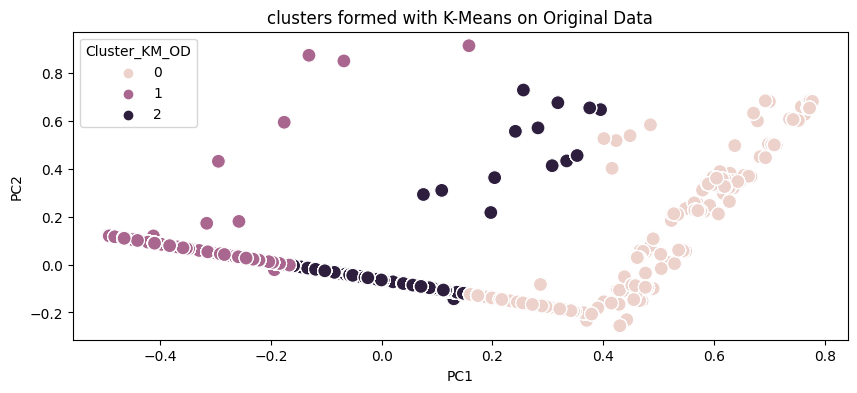

In [ ]:
sns.scatterplot(x='PC1', y='PC2', hue='Cluster_KM_OD', data=data, s=100)
plt.title('clusters formed with K-Means on Original Data')

silhouette_score for KMeans_PC = 0.6078314313043139
calinski_harabasz_score for KMeans_PC = 62889.67524729395
davies_bouldin_score for KMeans_PC = 0.4989926344476087


Text(0.5, 1.0, 'clusters formed with K-Means on PCA data')

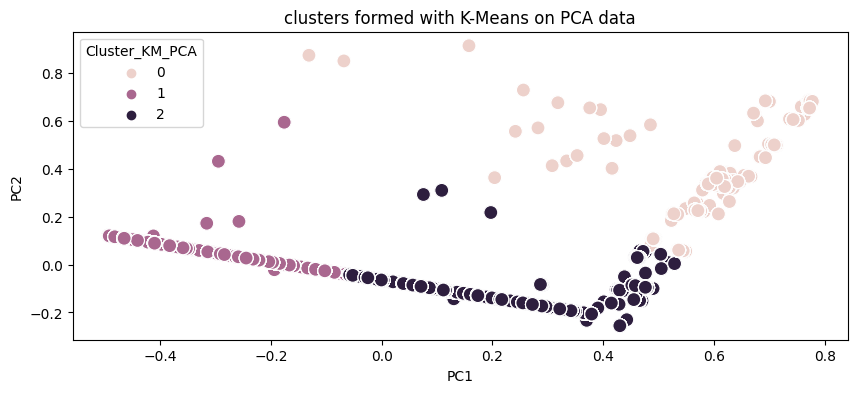

In [ ]:
Kmm_model = KMeans(n_clusters = 3)
Kmm_model.fit(data_red)
Kmm_clustrs = Kmm_model.labels_
data['Cluster_KM_PCA'] = Kmm_clustrs

# Evaluate clustering using metrics
print('silhouette_score for KMeans_PC =',silhouette_score(data_red.head(30000), data['Cluster_KM_PCA'].head(30000)))
print('calinski_harabasz_score for KMeans_PC =',calinski_harabasz_score(data_red.head(30000), data['Cluster_KM_PCA'].head(30000)))
print('davies_bouldin_score for KMeans_PC =',davies_bouldin_score(data_red.head(30000), data['Cluster_KM_PCA'].head(30000)))

sns.scatterplot(x='PC1', y='PC2', hue='Cluster_KM_PCA', data=data, s=100)
plt.title('clusters formed with K-Means on PCA data')

Applying ICA

In [ ]:
ica = FastICA(n_components=2)
df_ica = ica.fit_transform(data_rescaled)
data['IC1'],data['IC2']=df_ica[:,0],df_ica[:,1]
df_ica=pd.DataFrame(df_ica,columns=['IC1','IC2'])
df_ica

,IC1,IC2
0,0.002400,-0.000364
1,0.002400,-0.000364
2,0.002400,-0.000364
3,0.002400,-0.000364
4,0.002400,-0.000364
...,...,...
392687,-0.000954,0.004638
392688,-0.000954,0.004638
392689,-0.000954,0.004638
392690,-0.000954,0.004638


K Means on ICA Data

silhouette_score for KMeans_IC = 0.6124876121081546
silhouette_score for KMeans_IC = 65900.60287678018
silhouette_score for KMeans_IC = 0.47934738700597995


Text(0.5, 1.0, 'clusters formed with K-Means on ICA data')

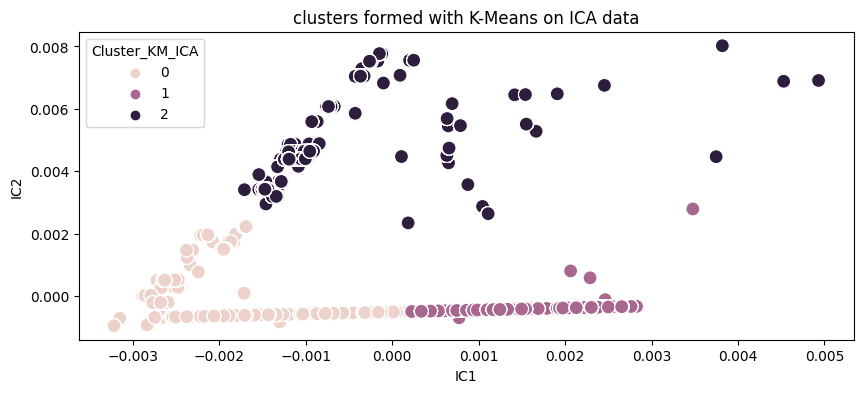

In [ ]:
Kmm_model = KMeans(n_clusters = 3)
Kmm_model.fit(df_ica)
Kmm_clustrs = Kmm_model.labels_
data['Cluster_KM_ICA'] = Kmm_clustrs

# Evaluate clustering using metrics
print('silhouette_score for KMeans_IC =',silhouette_score(df_ica.head(30000), data['Cluster_KM_ICA'].head(30000)))
print('silhouette_score for KMeans_IC =',calinski_harabasz_score(df_ica.head(30000), data['Cluster_KM_ICA'].head(30000)))
print('silhouette_score for KMeans_IC =',davies_bouldin_score(df_ica.head(30000), data['Cluster_KM_ICA'].head(30000)))

sns.scatterplot(x='IC1', y='IC2', hue='Cluster_KM_ICA', data=data, s=100)
plt.title('clusters formed with K-Means on ICA data')

##Clustering using KNN Clustering

In [ ]:
X_train_p, X_test_p, Y_train_p, Y_test_p = model_selection.train_test_split(data_red, data['Cluster_KM_PCA'], train_size=0.7)
X_train_i, X_test_i, Y_train_i, Y_test_i = model_selection.train_test_split(df_ica, data['Cluster_KM_ICA'], train_size=0.7)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_p, Y_train_p)
labels_knn_pca = knn.predict(X_test_p)
knn.fit(X_train_i, Y_train_i)
labels_knn_ica = knn.predict(X_test_i)

#### Performance evaluation and analysis

In [ ]:
accuracy_pca = accuracy_score(Y_test_p, labels_knn_pca)
precision_pca = precision_score(Y_test_p, labels_knn_pca, average='weighted')
recall_pca = recall_score(Y_test_p, labels_knn_pca, average='weighted')

accuracy_ica = accuracy_score(Y_test_i, labels_knn_ica)
precision_ica = precision_score(Y_test_i, labels_knn_ica, average='weighted')
recall_ica = recall_score(Y_test_i, labels_knn_ica, average='weighted')

print('PCA - Accuracy:', accuracy_pca, 'Precision:', precision_pca, 'Recall:', recall_pca)
print('ICA - Accuracy:', accuracy_ica, 'Precision:', precision_ica, 'Recall:', recall_ica)

PCA - Accuracy: 1.0 Precision: 1.0 Recall: 1.0
ICA - Accuracy: 1.0 Precision: 1.0 Recall: 1.0


###Description on each cluster formed

In [ ]:
(data[data['Cluster_KM_OD']==0].copy()).describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,121854.0,14.670105,216.856505,1.0,3.0,6.0,12.0,74215.0
UnitPrice,121854.0,3.476195,27.306175,0.001,1.25,1.95,3.75,4161.06
CustomerID,121854.0,13271.536765,571.198041,12346.0,12748.0,13230.0,13790.0,14206.0
Country,121854.0,29.673273,9.680299,0.0,30.0,35.0,35.0,36.0
Amount,121854.0,25.036972,229.093272,0.001,7.5,15.0,20.8,77183.6
days_since_last_purchase,121854,150 days 20:29:57.274607320,111 days 12:37:25.926264706,1 days 00:00:00,50 days 23:44:00,130 days 03:15:00,246 days 00:56:00,374 days 04:16:00
days_since_last_purchase_num,121854.0,150.336099,111.541052,1.0,50.0,130.0,246.0,374.0
PC1,121854.0,0.34848,0.163728,0.149224,0.220295,0.310276,0.451588,0.77769
PC2,121854.0,-0.037378,0.233972,-0.255653,-0.178185,-0.146069,-0.089147,0.684764
Cluster_KM_OD,121854.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Text(0.5, 1.0, 'corr_matrix for cluster 0')

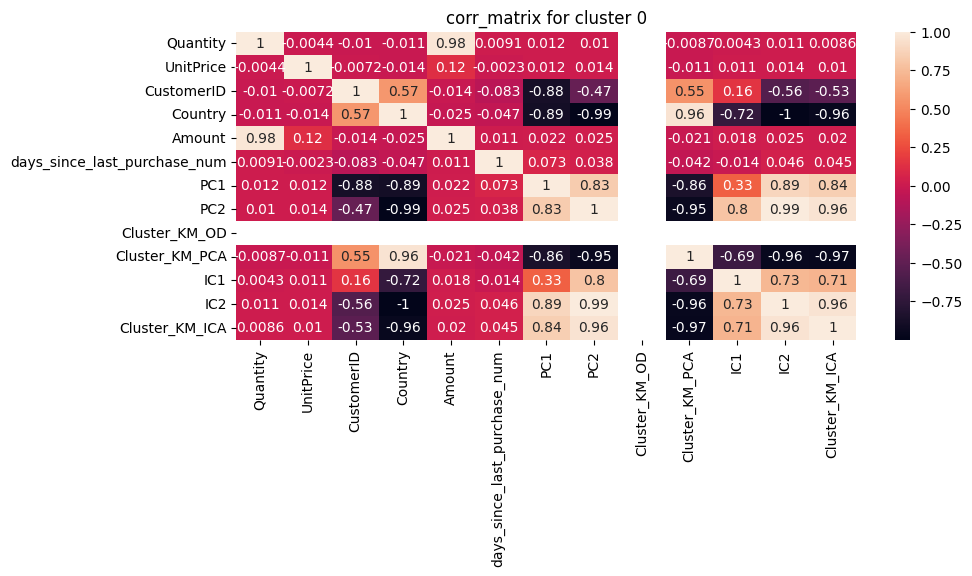

In [ ]:
sns.heatmap((data[data['Cluster_KM_OD']==0].copy()).corr(),annot=True)
plt.title('corr_matrix for cluster 0')

In [ ]:
(data[data['Cluster_KM_OD']==1].copy()).describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,133716.0,12.621414,226.444977,1.0,2.0,4.0,12.0,80995.0
UnitPrice,133716.0,2.857553,9.078519,0.04,1.25,1.79,3.75,2033.1
CustomerID,133716.0,17273.031956,579.223695,16207.0,16767.0,17320.0,17799.0,18287.0
Country,133716.0,34.941802,1.12688,0.0,35.0,35.0,35.0,36.0
Amount,133716.0,22.038366,469.058946,0.12,3.75,9.9,17.4,168469.6
days_since_last_purchase,133716,153 days 02:02:44.393789822,114 days 06:46:47.355656154,1 days 00:29:00,49 days 23:33:00,132 days 02:10:00,248 days 21:29:00,374 days 04:24:00
days_since_last_purchase_num,133716.0,152.543742,114.295575,1.0,49.0,132.0,248.0,374.0
PC1,133716.0,-0.333529,0.091818,-0.493884,-0.416982,-0.34071,-0.253881,0.15759
PC2,133716.0,0.062305,0.04533,-0.021589,0.030858,0.063747,0.092613,0.914688
Cluster_KM_OD,133716.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


Text(0.5, 1.0, 'corr_matrix for cluster 1')

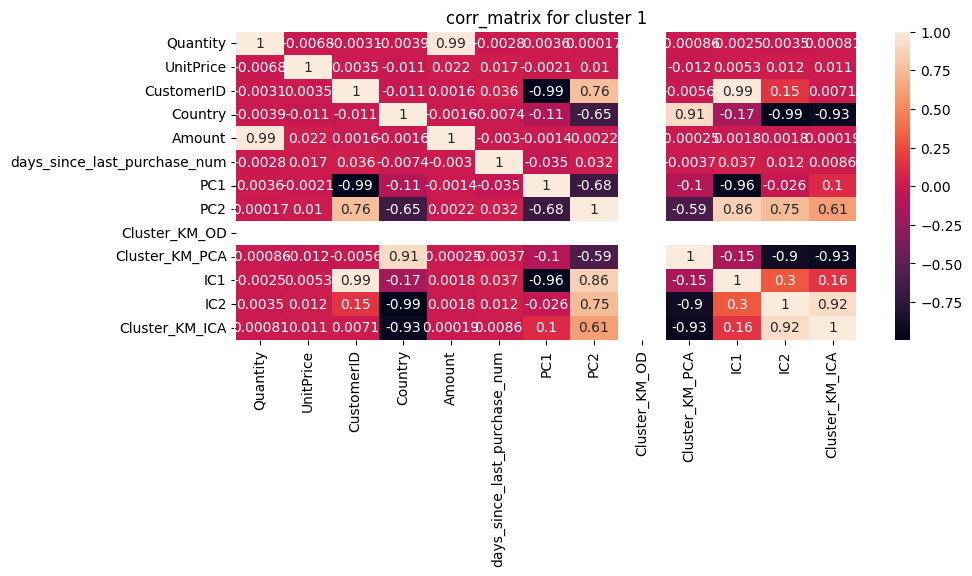

In [ ]:
sns.heatmap((data[data['Cluster_KM_OD']==1].copy()).corr(),annot=True)
plt.title('corr_matrix for cluster 1')

In [ ]:
(data[data['Cluster_KM_OD']==2].copy()).describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,137122.0,12.227841,38.724229,1.0,2.0,5.0,12.0,3186.0
UnitPrice,137122.0,3.076331,25.953339,0.001,1.25,1.95,3.75,8142.75
CustomerID,137122.0,15143.765413,561.254889,14208.0,14649.0,15050.0,15615.0,16206.0
Country,137122.0,33.553463,5.662455,5.0,35.0,35.0,35.0,36.0
Amount,137122.0,21.072268,126.37303,0.001,4.56,11.25,19.5,38970.0
days_since_last_purchase,137122,154 days 01:29:04.667522350,112 days 02:10:40.733261262,1 days 00:19:00,51 days 23:12:00,134 days 21:34:00,247 days 21:48:00,374 days 03:41:00
days_since_last_purchase_num,137122.0,153.5337,112.110727,1.0,51.0,134.0,247.0,374.0
PC1,137122.0,0.015566,0.110192,-0.165948,-0.072815,0.016852,0.093123,0.395124
PC2,137122.0,-0.027541,0.146707,-0.143146,-0.093006,-0.061182,-0.028471,0.729469
Cluster_KM_OD,137122.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0


Text(0.5, 1.0, 'corr_matrix for cluster 2')

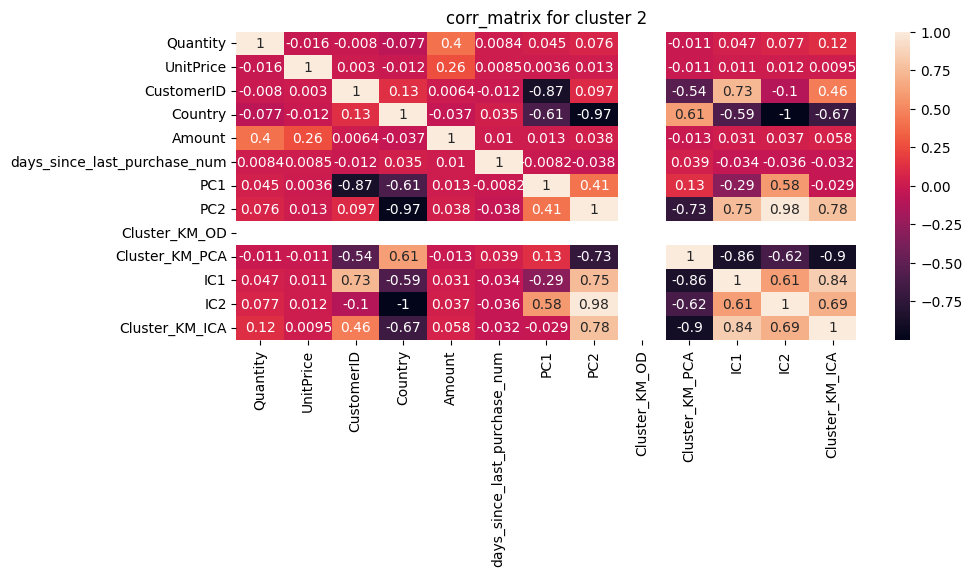

In [ ]:
sns.heatmap((data[data['Cluster_KM_OD']==2].copy()).corr(),annot=True)
plt.title('corr_matrix for cluster 2')

##Clustering using Hierarchical Clustering
#### Determine optimal number of clusters using dendrogram

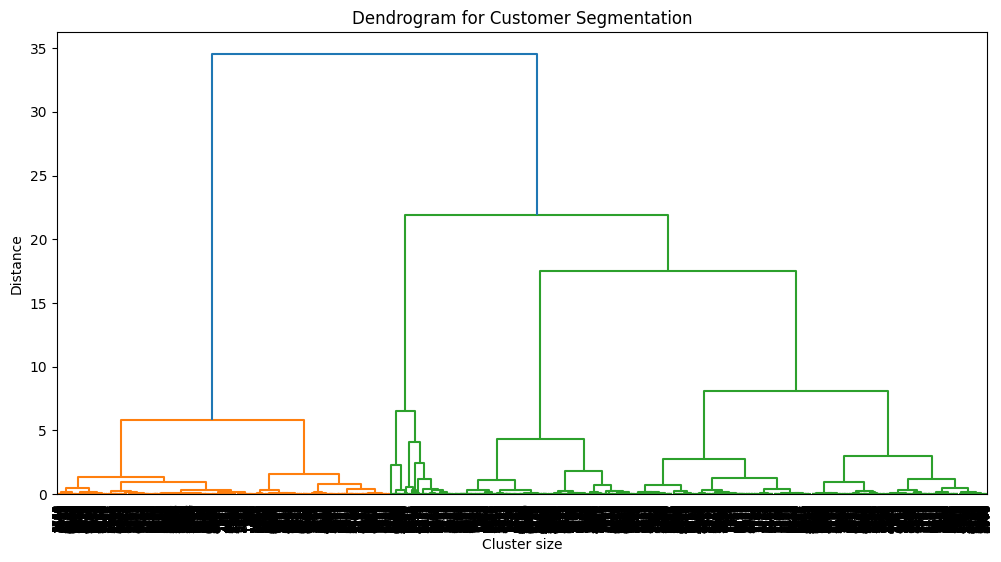

In [ ]:
# converting scaled data into a distance matrix using pdist
d_matrix = linkage(data_rescaled[0:10000,:], method='ward')

plt.figure(figsize=(12, 6))
dendrogram(d_matrix, leaf_rotation=90., leaf_font_size=8.,)
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.title('Dendrogram for Customer Segmentation')
plt.show()

#### Performing clustering using Hierarchical Clustering on PCA Data

In [ ]:
agg_cluster = AgglomerativeClustering(n_clusters=3)
agg_cluster.fit(data_red)
data['Cluster_agg_PC']=agg_cluster.labels_
# Evaluate clustering using metrics
print('silhouette_score for AgglomerativeClustering_PCA',silhouette_score(data_red.head(30000), agg_cluster.labels_.head(30000)))
print('calinski_harabasz_score for AgglomerativeClustering_PCA',calinski_harabasz_score(data_red.head(30000), agg_cluster.labels_.head(30000)))
print('davies_bouldin_score for AgglomerativeClustering_PCA',davies_bouldin_score(data_red.head(30000), agg_cluster.labels_.head(30000)))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster_agg_PC', data=data, s=100)
plt.title('clusters formed with AGG on PCA data')

#### Performing clustering using Hierarchical Clustering on ICA Data

In [ ]:
agg_cluster = AgglomerativeClustering(n_clusters=3)
agg_cluster.fit(df_ica)
data['Cluster_agg_IC']=agg_cluster.labels_
# Evaluate clustering using metrics
print('silhouette_score for AgglomerativeClustering_ICA',silhouette_score(df_ica.head(30000), agg_cluster.labels_.head(30000)))
print('calinski_harabasz_score for AgglomerativeClustering_ICA',calinski_harabasz_score(df_ica.head(30000), agg_cluster.labels_.head(30000)))
print('davies_bouldin_score for AgglomerativeClustering_ICA',davies_bouldin_score(df_ica.head(30000), agg_cluster.labels_.head(30000)))
sns.scatterplot(x='IC1', y='IC2', hue='Cluster_agg_IC', data=data, s=100)
plt.title('clusters formed with AGG on ICA data')